# Unary Decompositions

This notebook is the first step in a gradual tour of `abstractgraph` operators. It focuses only on unary decompositions: operators that take one `AbstractGraph` and produce a new `AbstractGraph` by extracting one family of mapped subgraphs at a time.

Next: [02 Composition And Add](./example_abstract_graph_operators_02_composition_and_add.ipynb)


## What you will see

For each unary operator below, we will:

1. Look at a small base graph.
2. Draw the operator DAG.
3. Build the resulting `AbstractGraph`.
4. Visualize the interpretation graph and the base-to-interpretation mappings.

The goal here is not exhaustiveness. It is to make the basic decomposition vocabulary concrete before moving on to composition, filtering, and binary operators.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
from IPython.core.display import HTML
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')


In [3]:
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display, display_decomposition_graph, display_graph, display_mappings
from abstractgraph.operators import *


def draw(graph, decomposition_function, *, nbits=11, size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(graph, decomposition_function=decomposition_function, nbits=nbits)
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag


## A small graph with cycles and branches

This example graph is deliberately hand-built so the notebook runs from a clean checkout. It contains a 4-cycle, a triangle, and a short branch, which gives the unary operators something nontrivial to extract.


Graph with 8 nodes and 9 edges


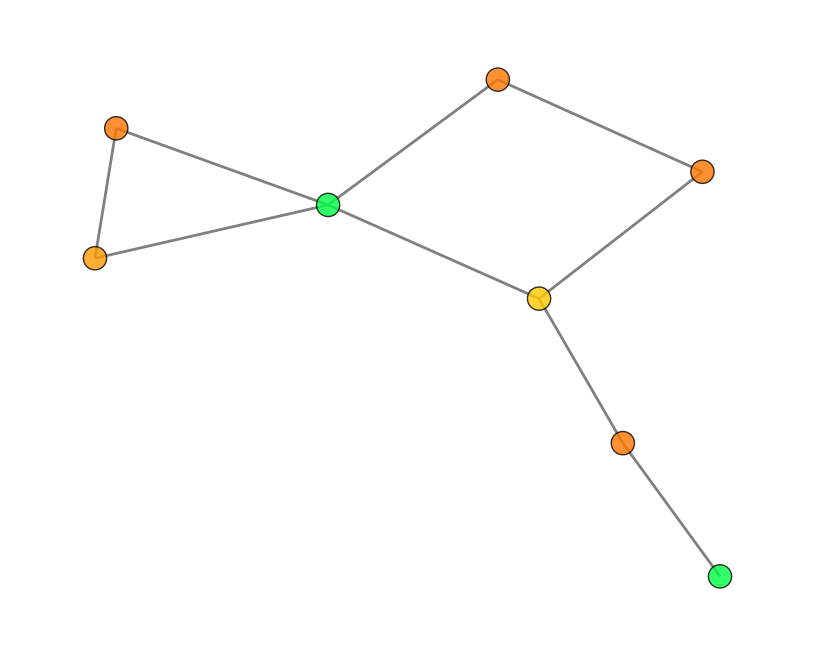

In [4]:
graph = nx.Graph()
graph.add_nodes_from([
    (0, {'label': 'C'}),
    (1, {'label': 'C'}),
    (2, {'label': 'O'}),
    (3, {'label': 'N'}),
    (4, {'label': 'C'}),
    (5, {'label': 'S'}),
    (6, {'label': 'C'}),
    (7, {'label': 'O'}),
])
graph.add_edges_from([
    (0, 1), (1, 2), (2, 3), (3, 0),
    (2, 4), (4, 5), (5, 2),
    (3, 6), (6, 7),
])

print(graph)
display_graph(graph)


## `node()`

Start with the finest possible decomposition: one interpretation node per base node.


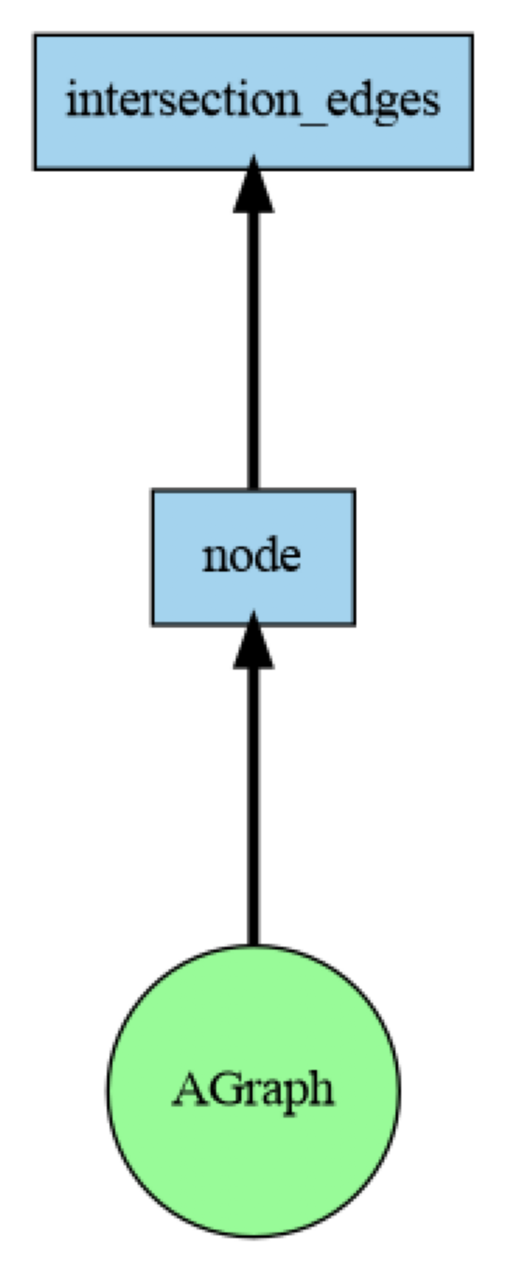

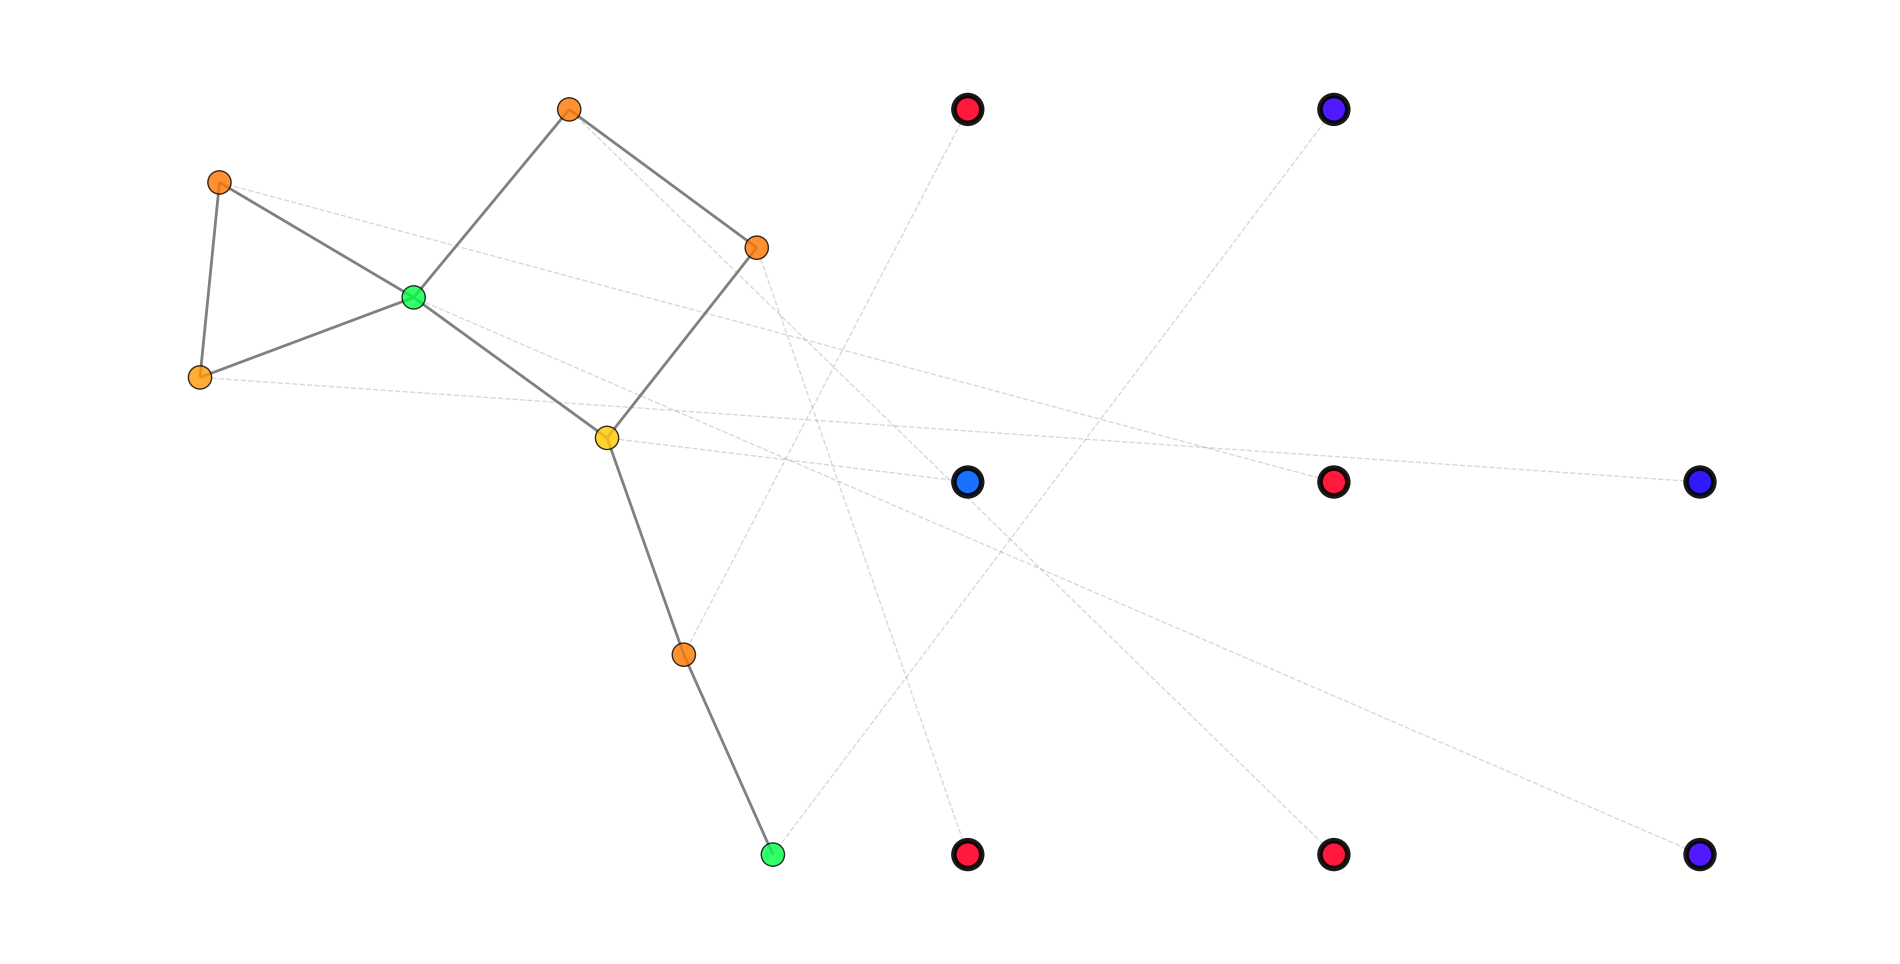

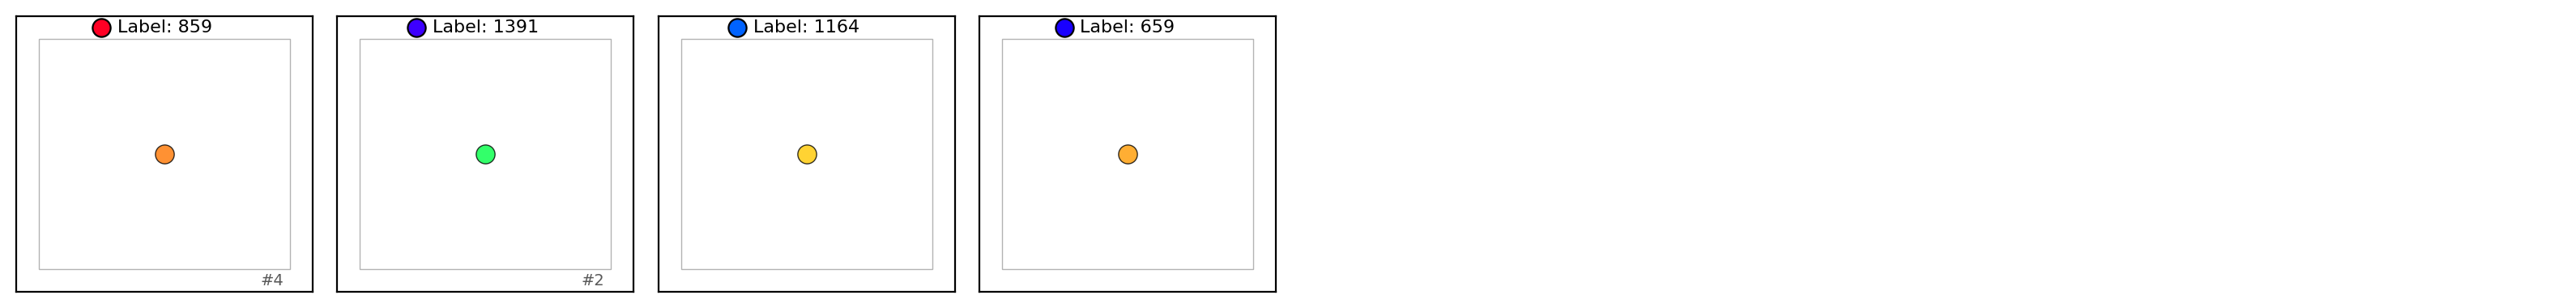

In [5]:
df = compose(intersection_edges(), node())
node_ag = draw(graph, df)


## `edge()`

Now each interpretation node represents a single base edge.


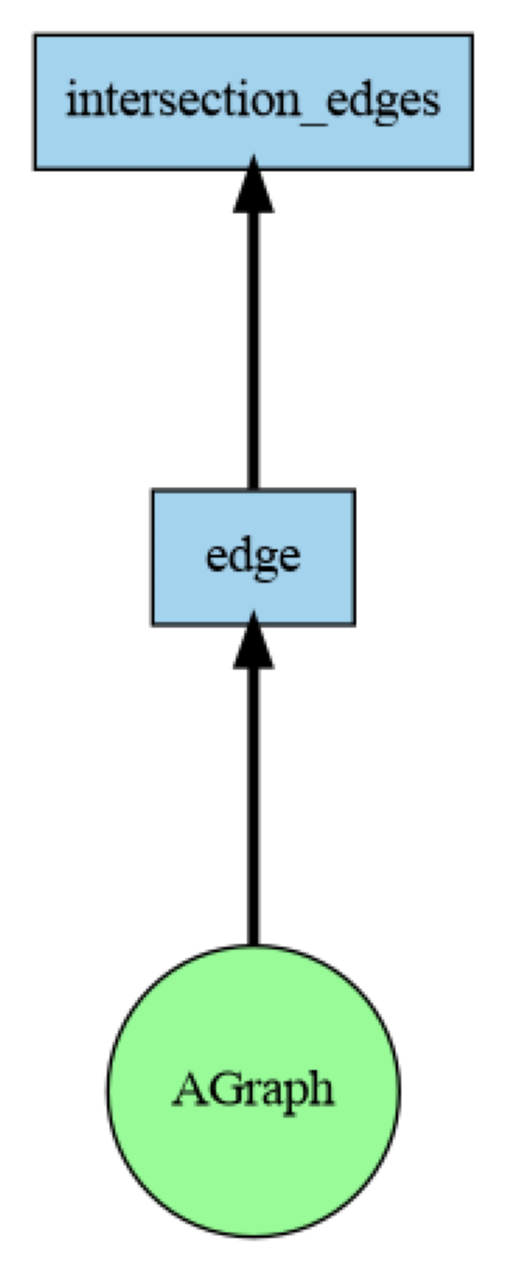

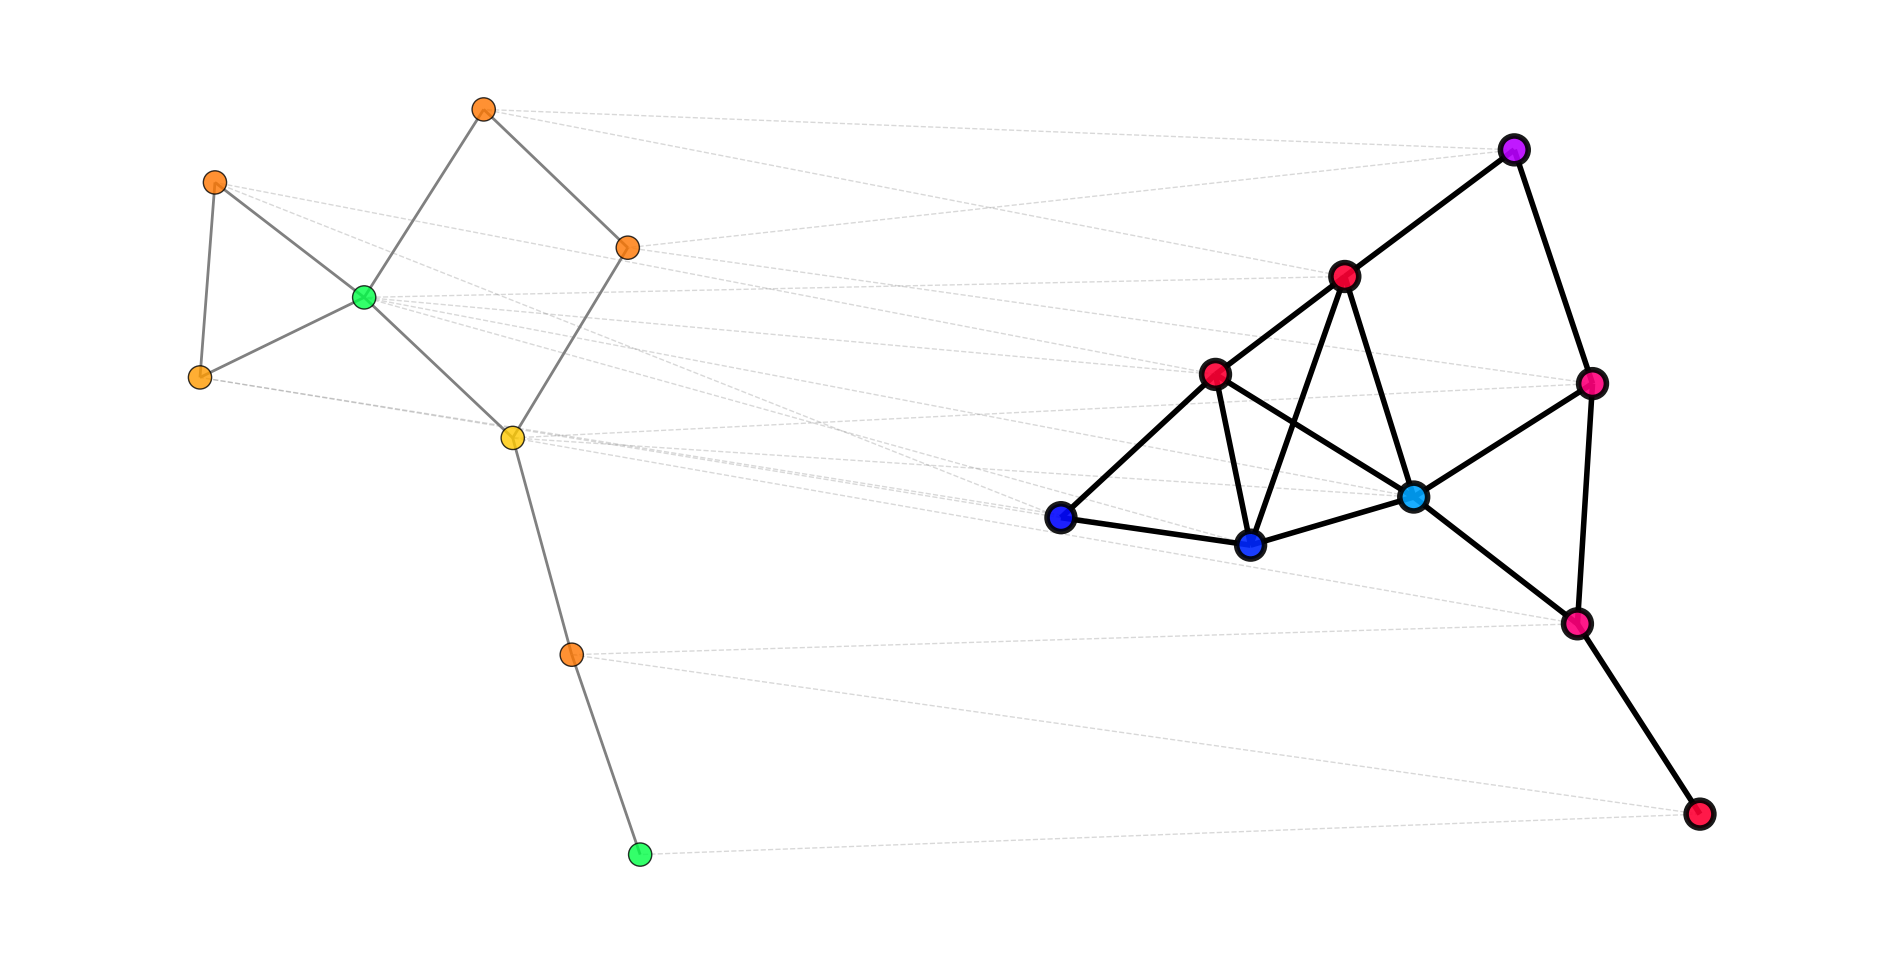

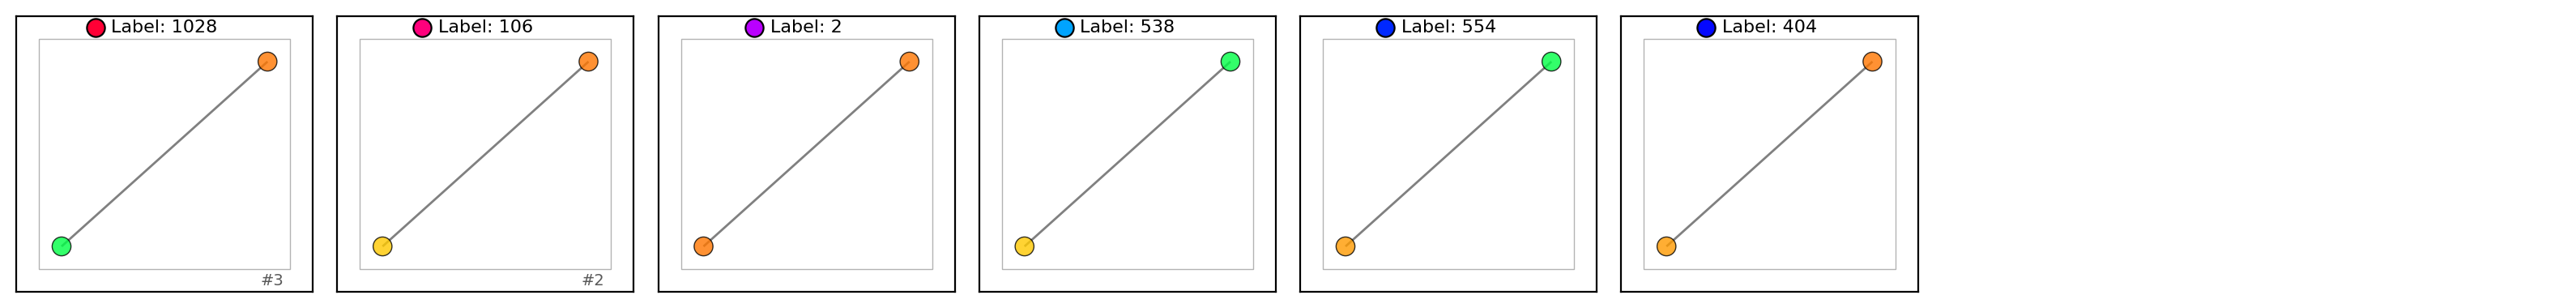

In [6]:
df = compose(intersection_edges(), edge())
edge_ag = draw(graph, df)


## `connected_component()`

This groups the graph into connected components. Our toy graph is connected, so the result should collapse to one mapped subgraph.


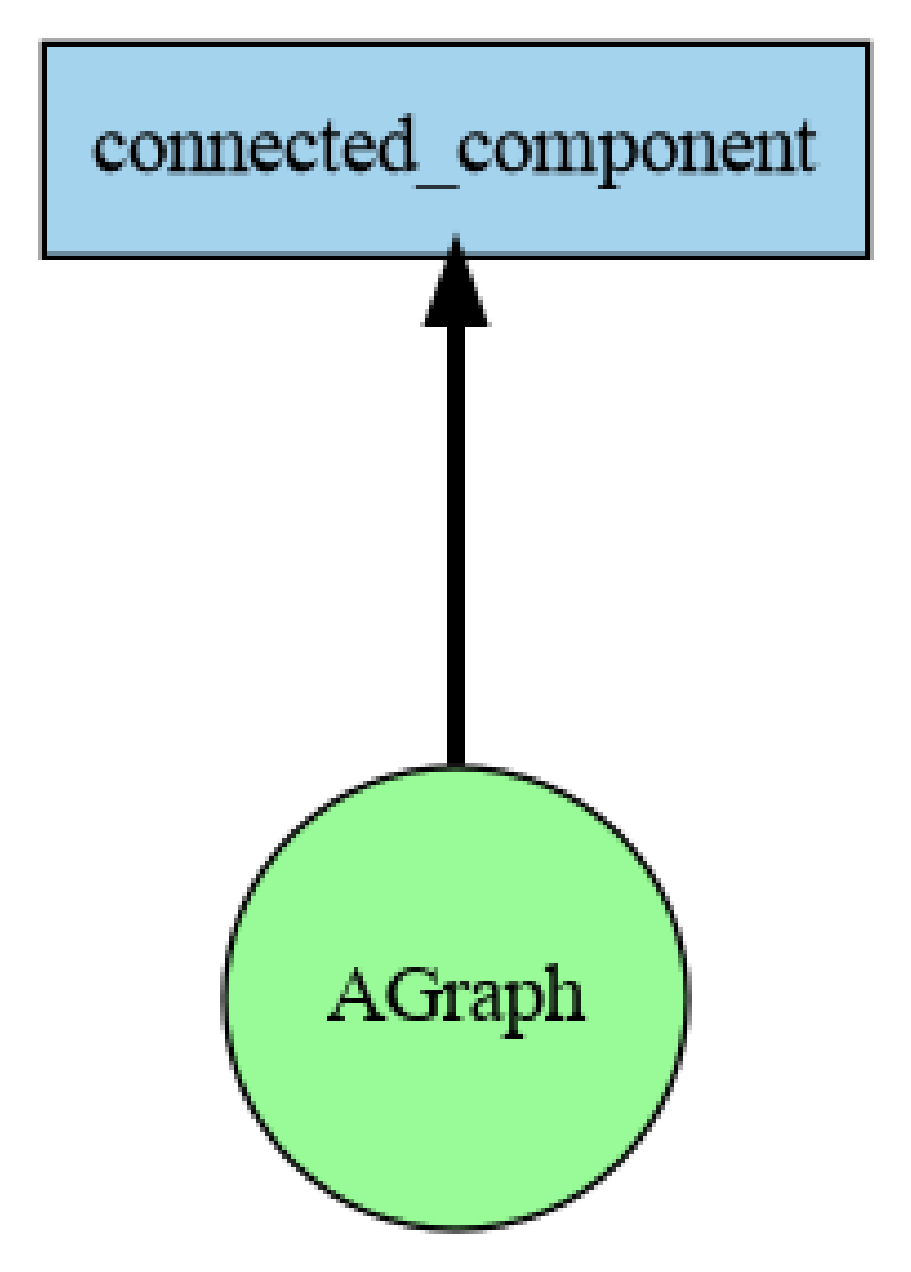

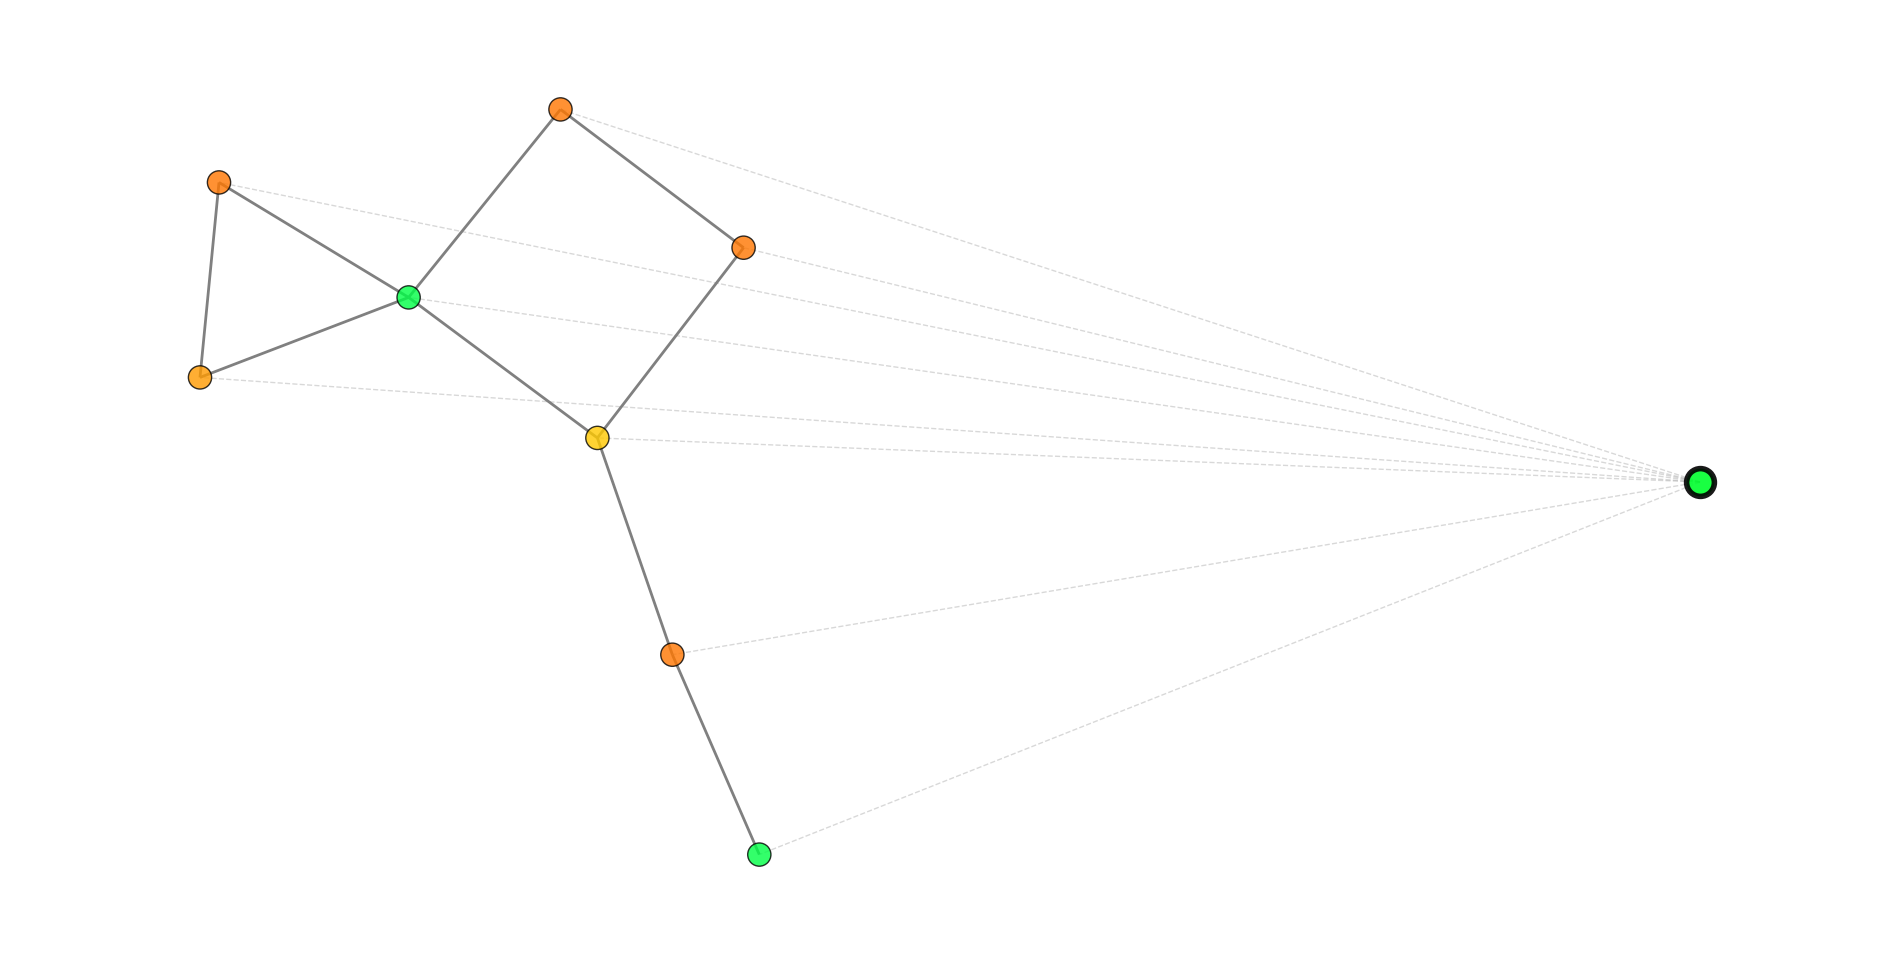

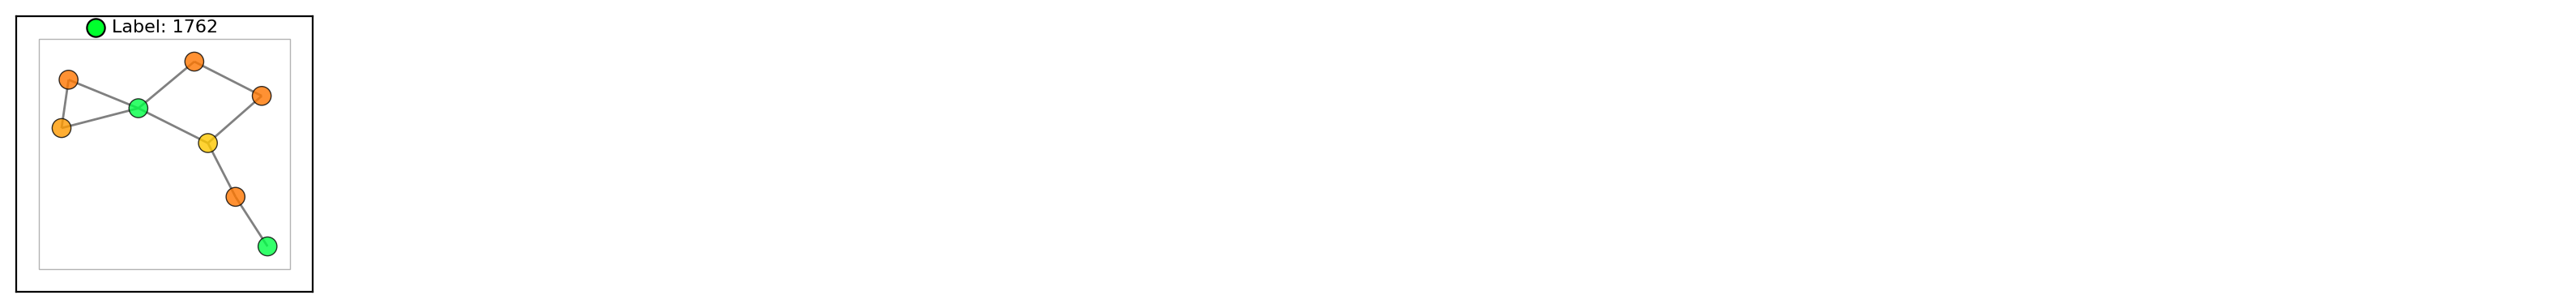

In [7]:
df = connected_component()
connected_component_ag = draw(graph, df)


## `neighborhood(radius=1)`

Neighborhood decomposition extracts ego-graphs centered at each node. This is one of the most useful local structural operators.


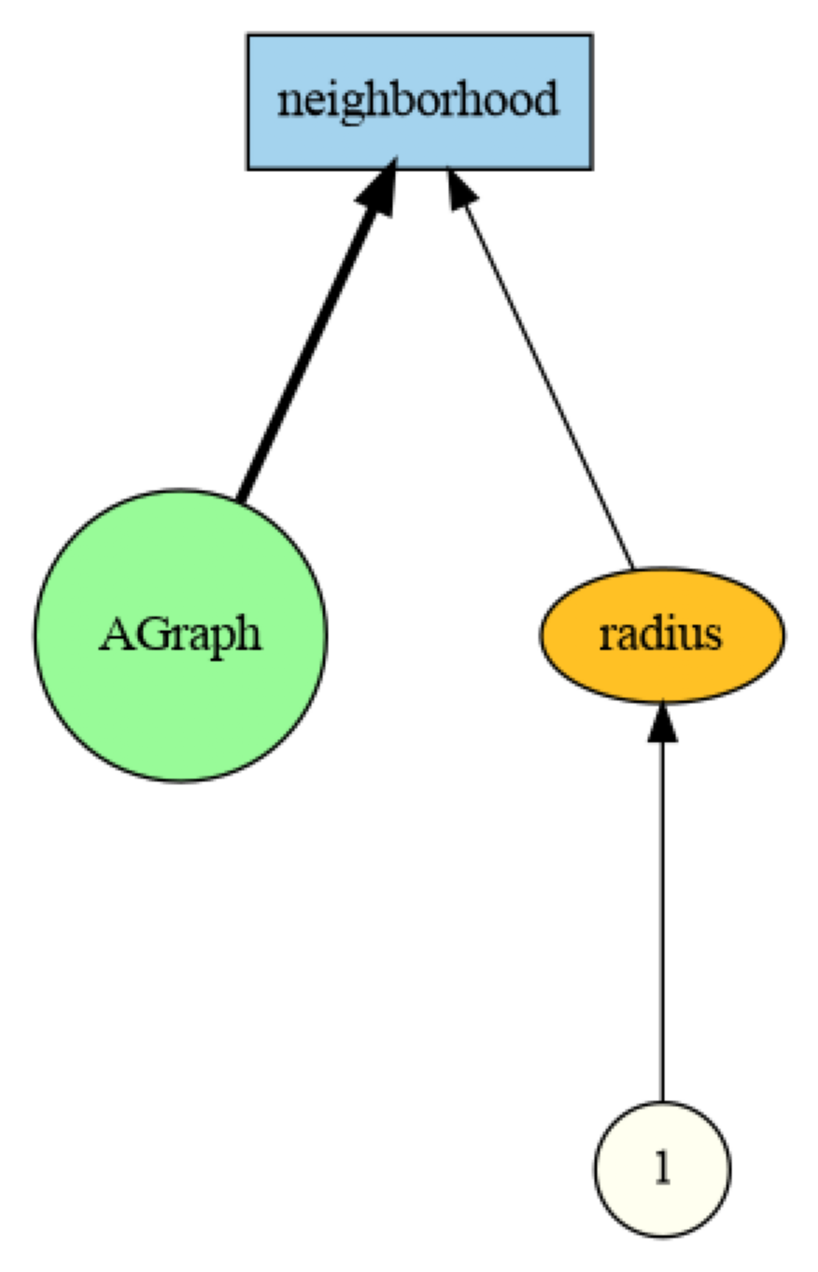

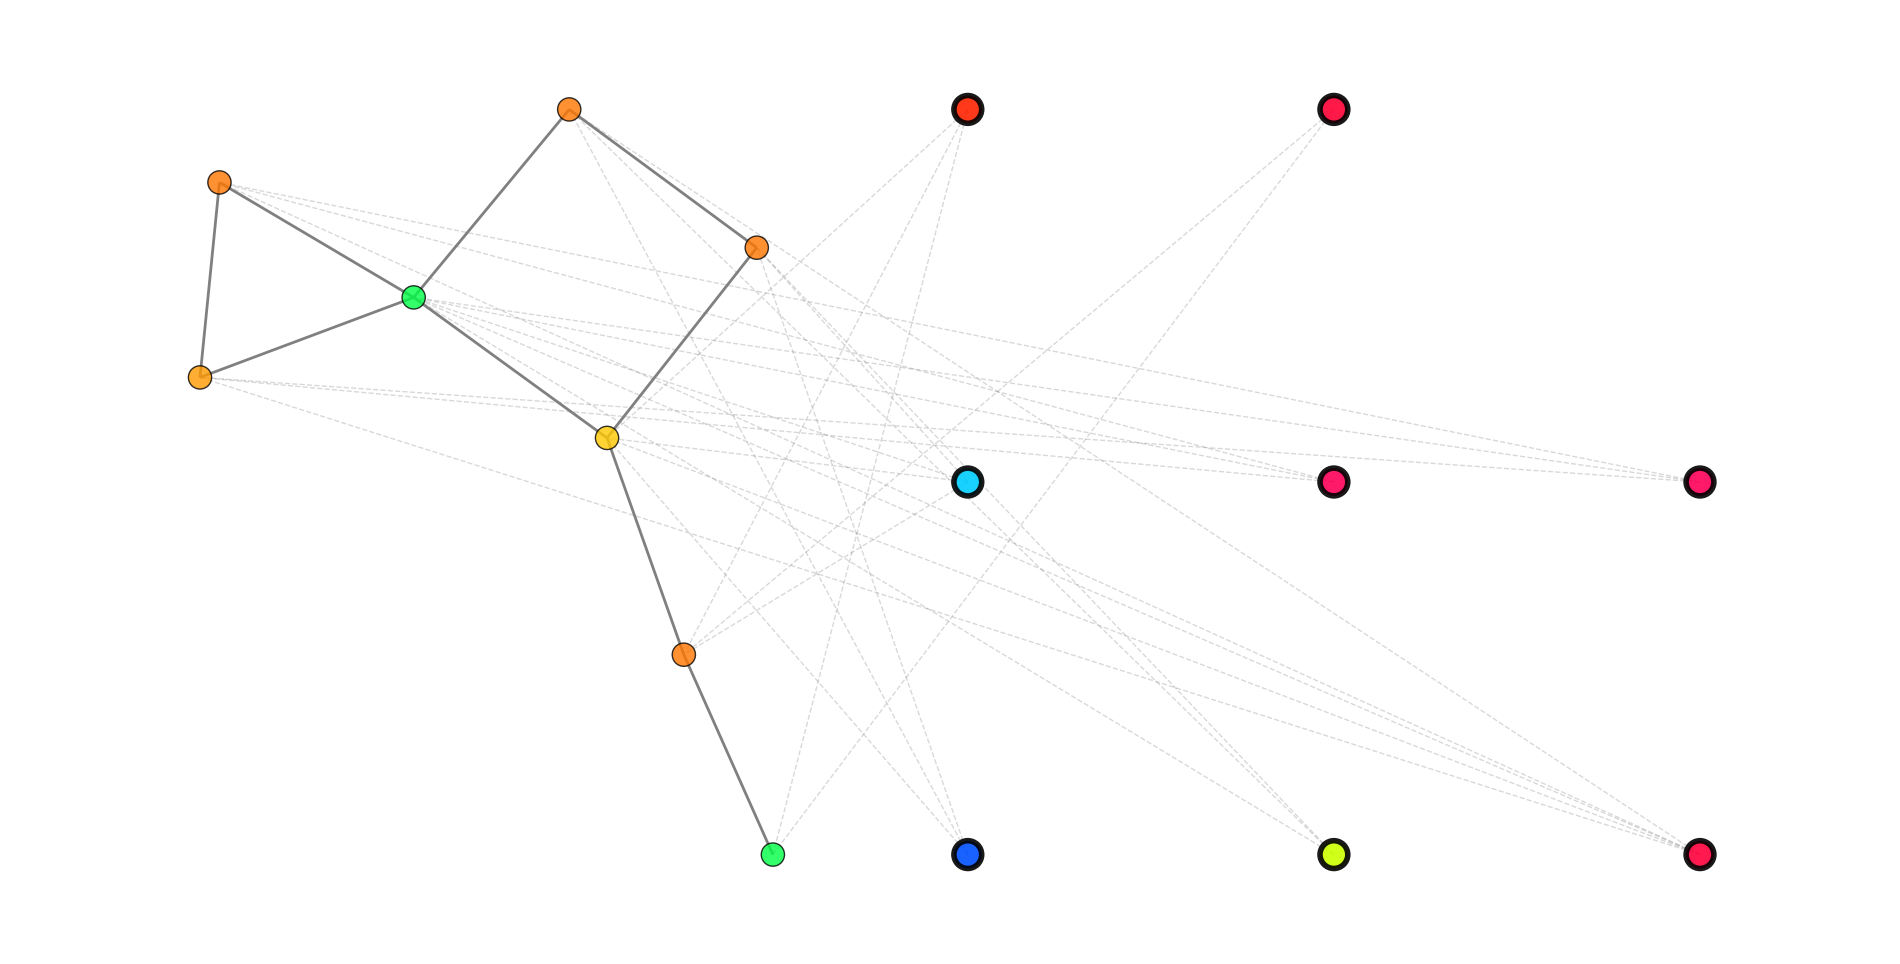

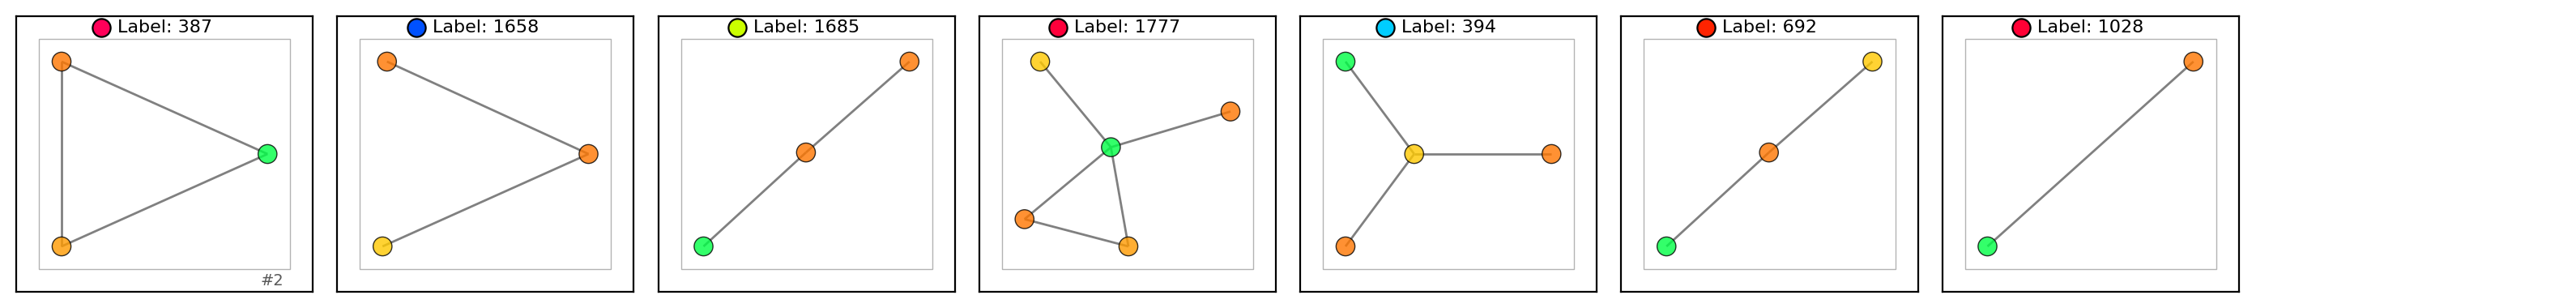

In [8]:
df = neighborhood(radius=1)
neighborhood_ag = draw(graph, df)


## `cycle()`

Cycle decomposition extracts simple cycles present in the base graph.


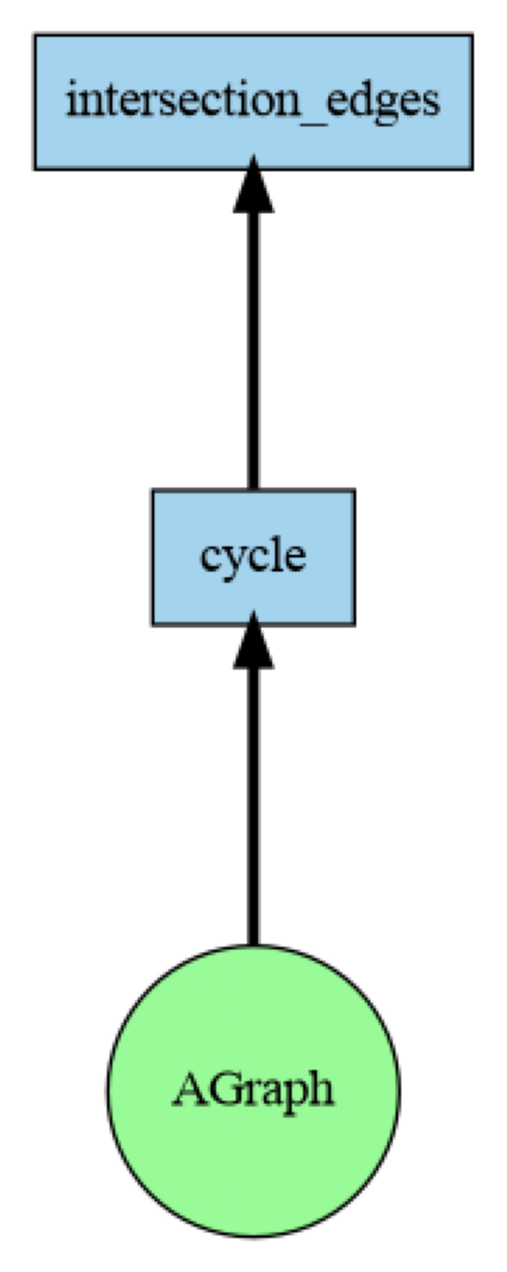

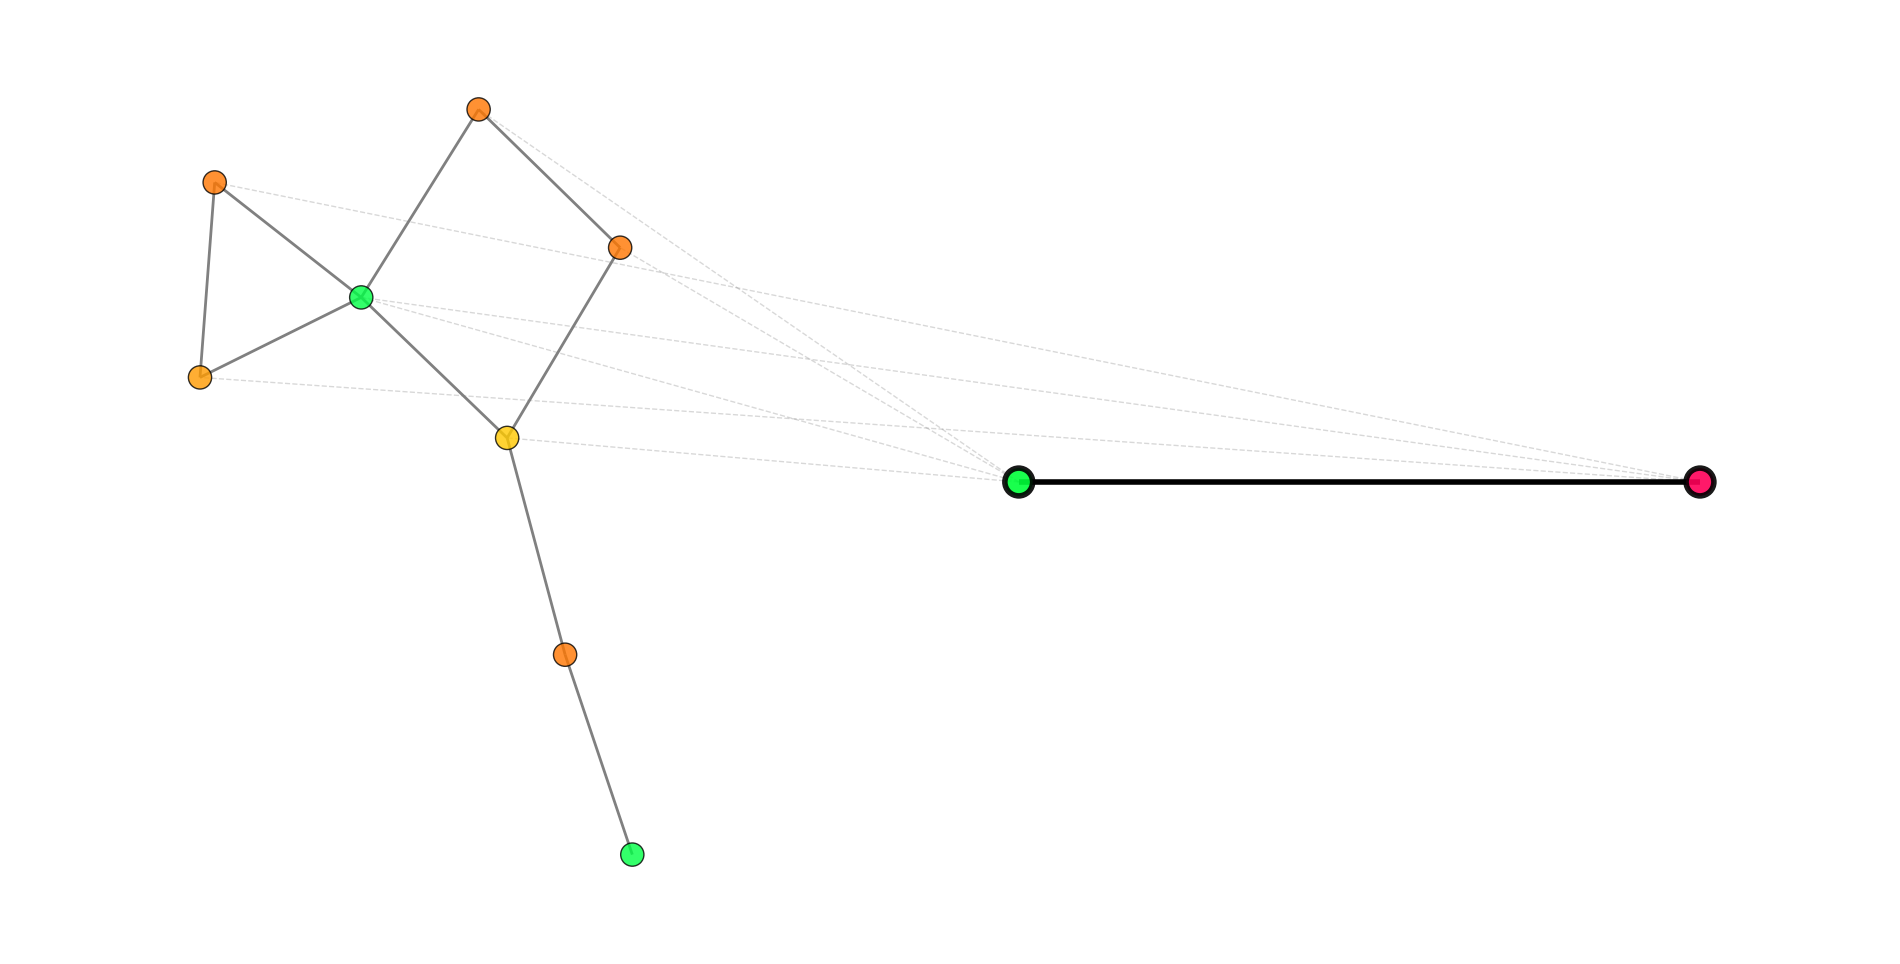

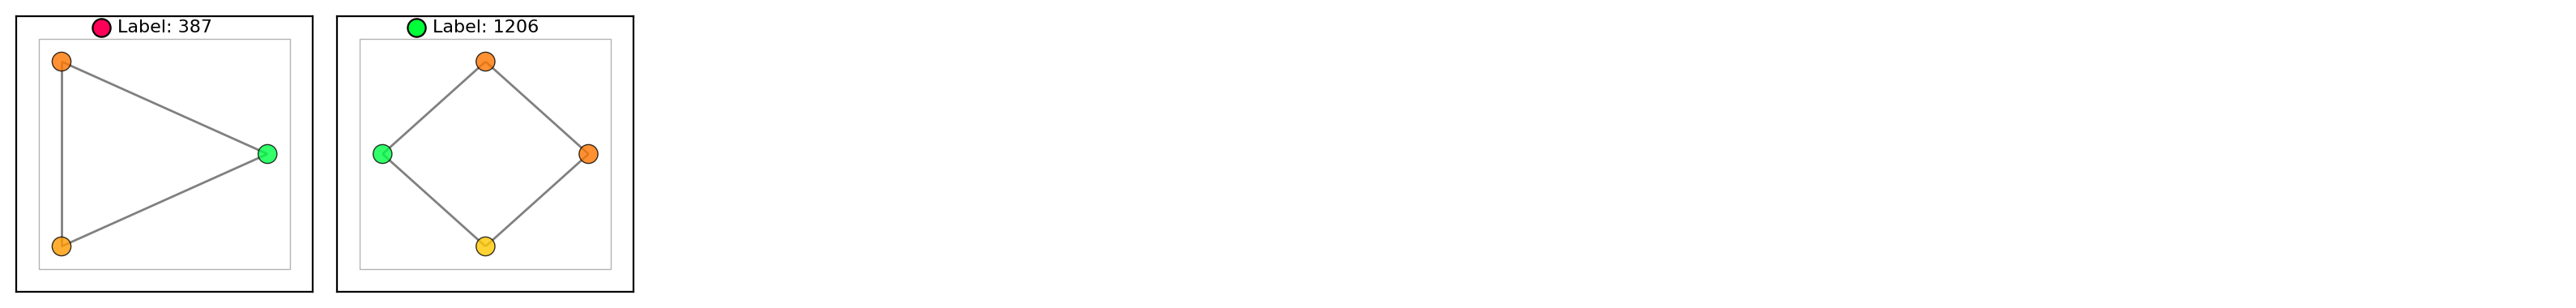

In [9]:
df = compose(intersection_edges(), cycle())
cycle_ag = draw(graph, df)


## `tree()`

Tree decomposition captures tree-structured mapped subgraphs.


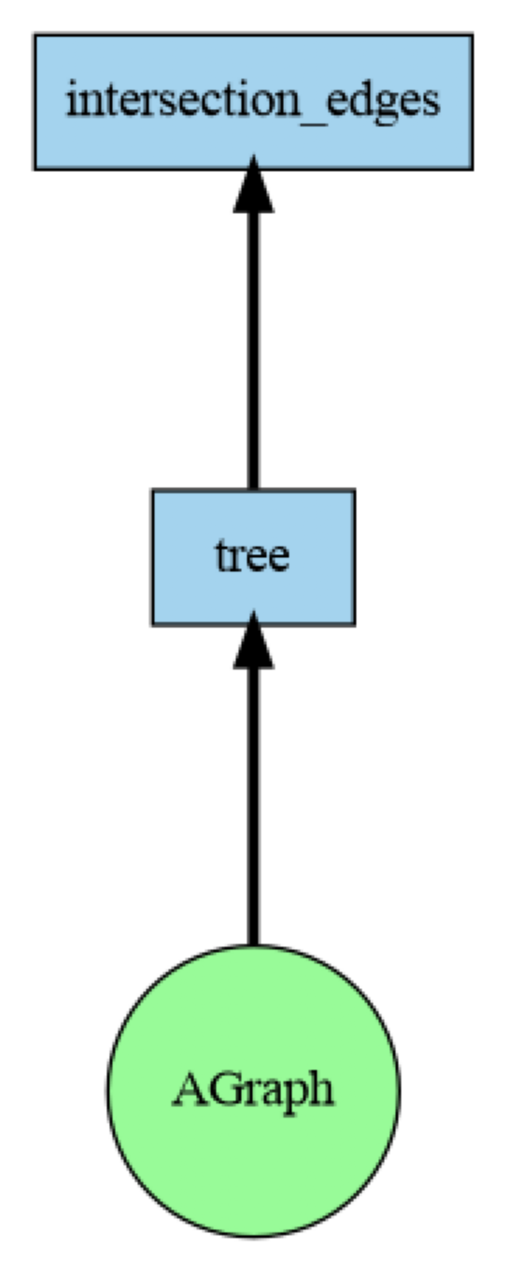

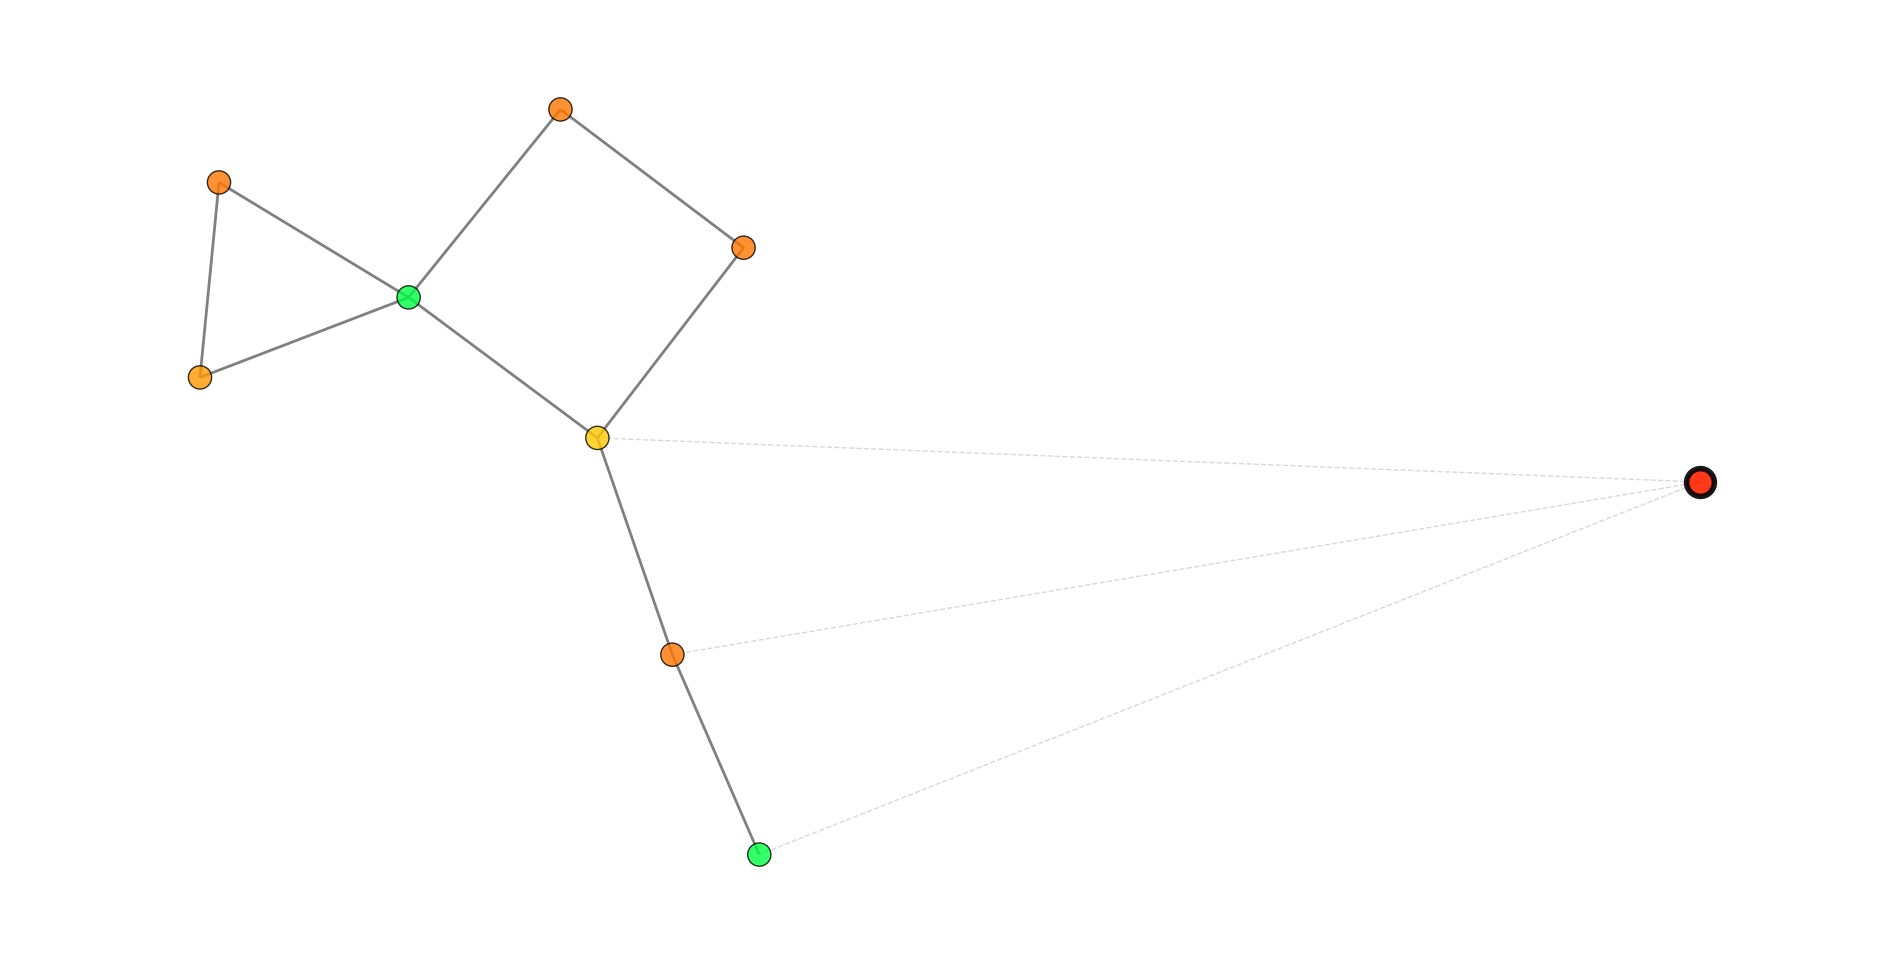

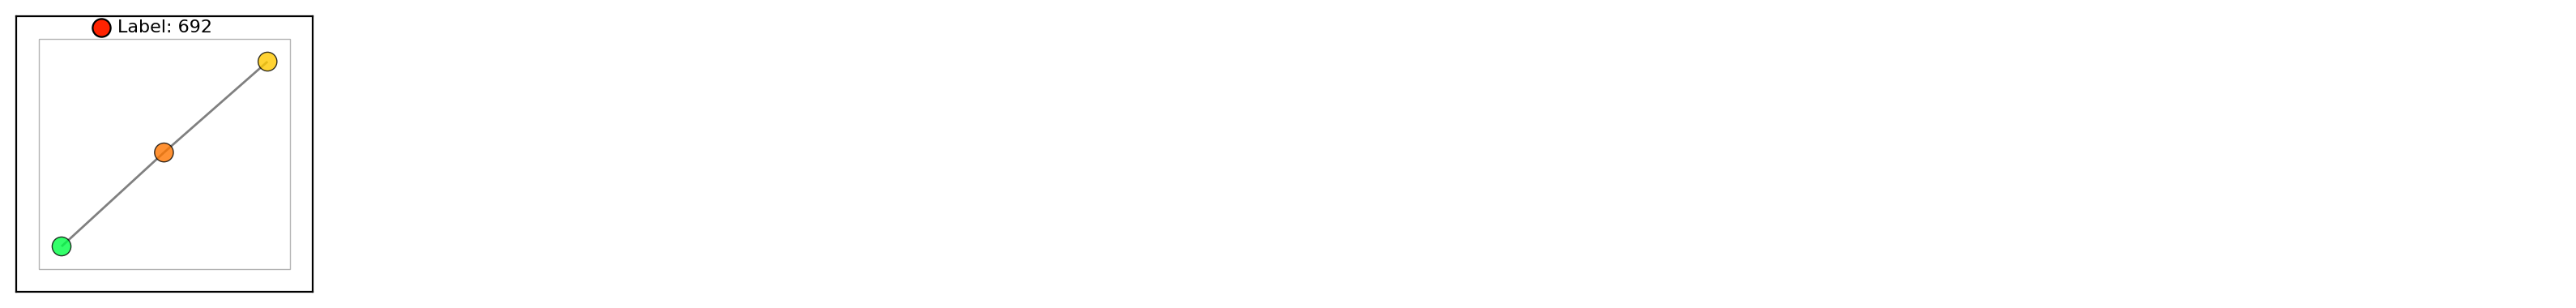

In [10]:
df = compose(intersection_edges(), tree())
tree_ag = draw(graph, df)


## `path(number_of_edges=(2, 3))`

Path decomposition enumerates bounded simple paths. Restricting the length keeps the output readable.


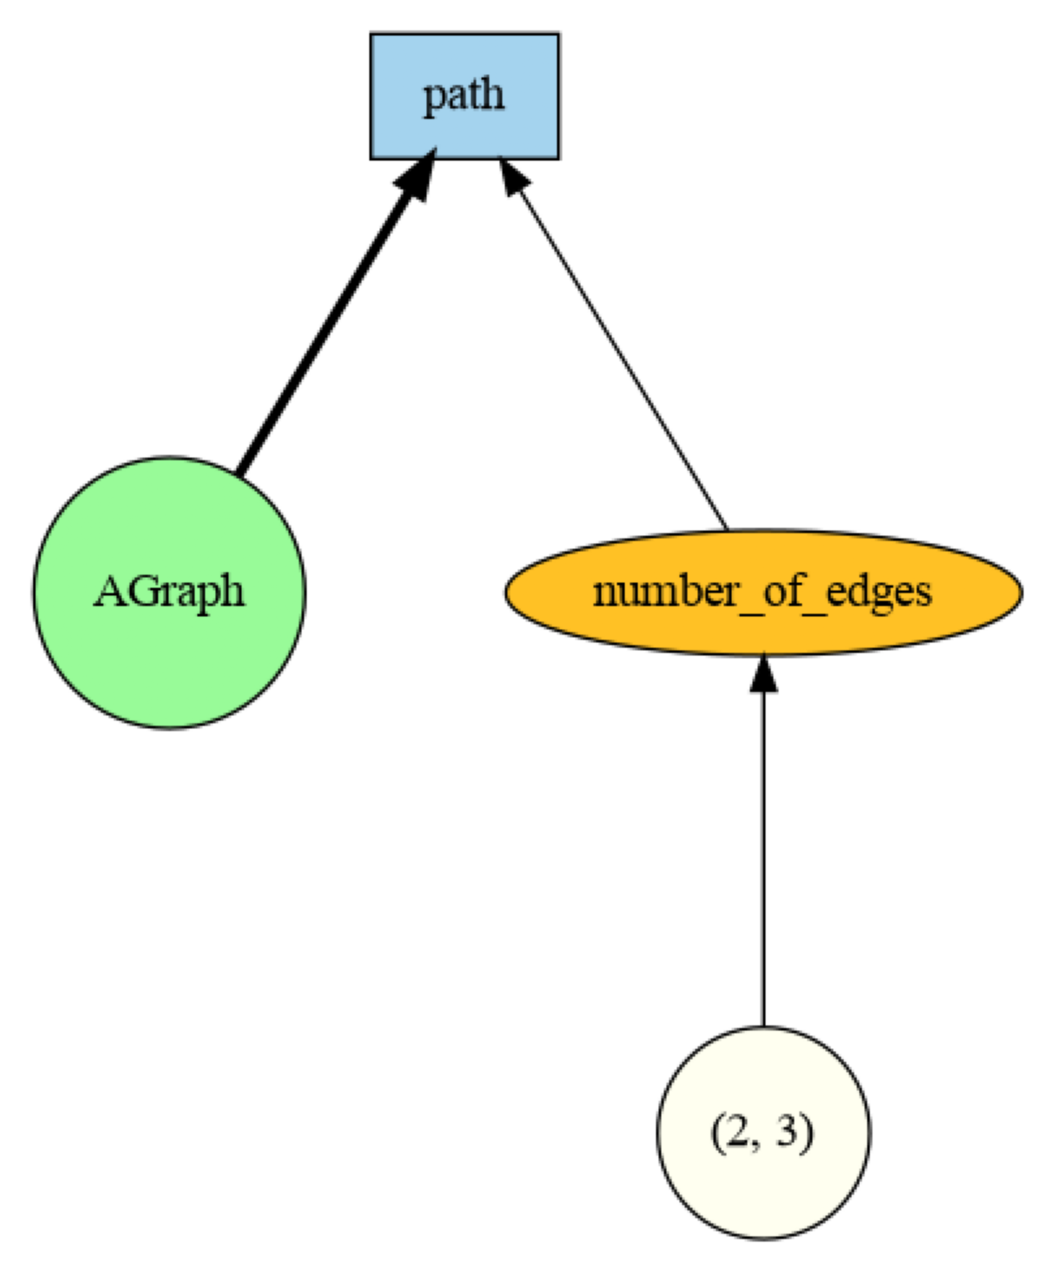

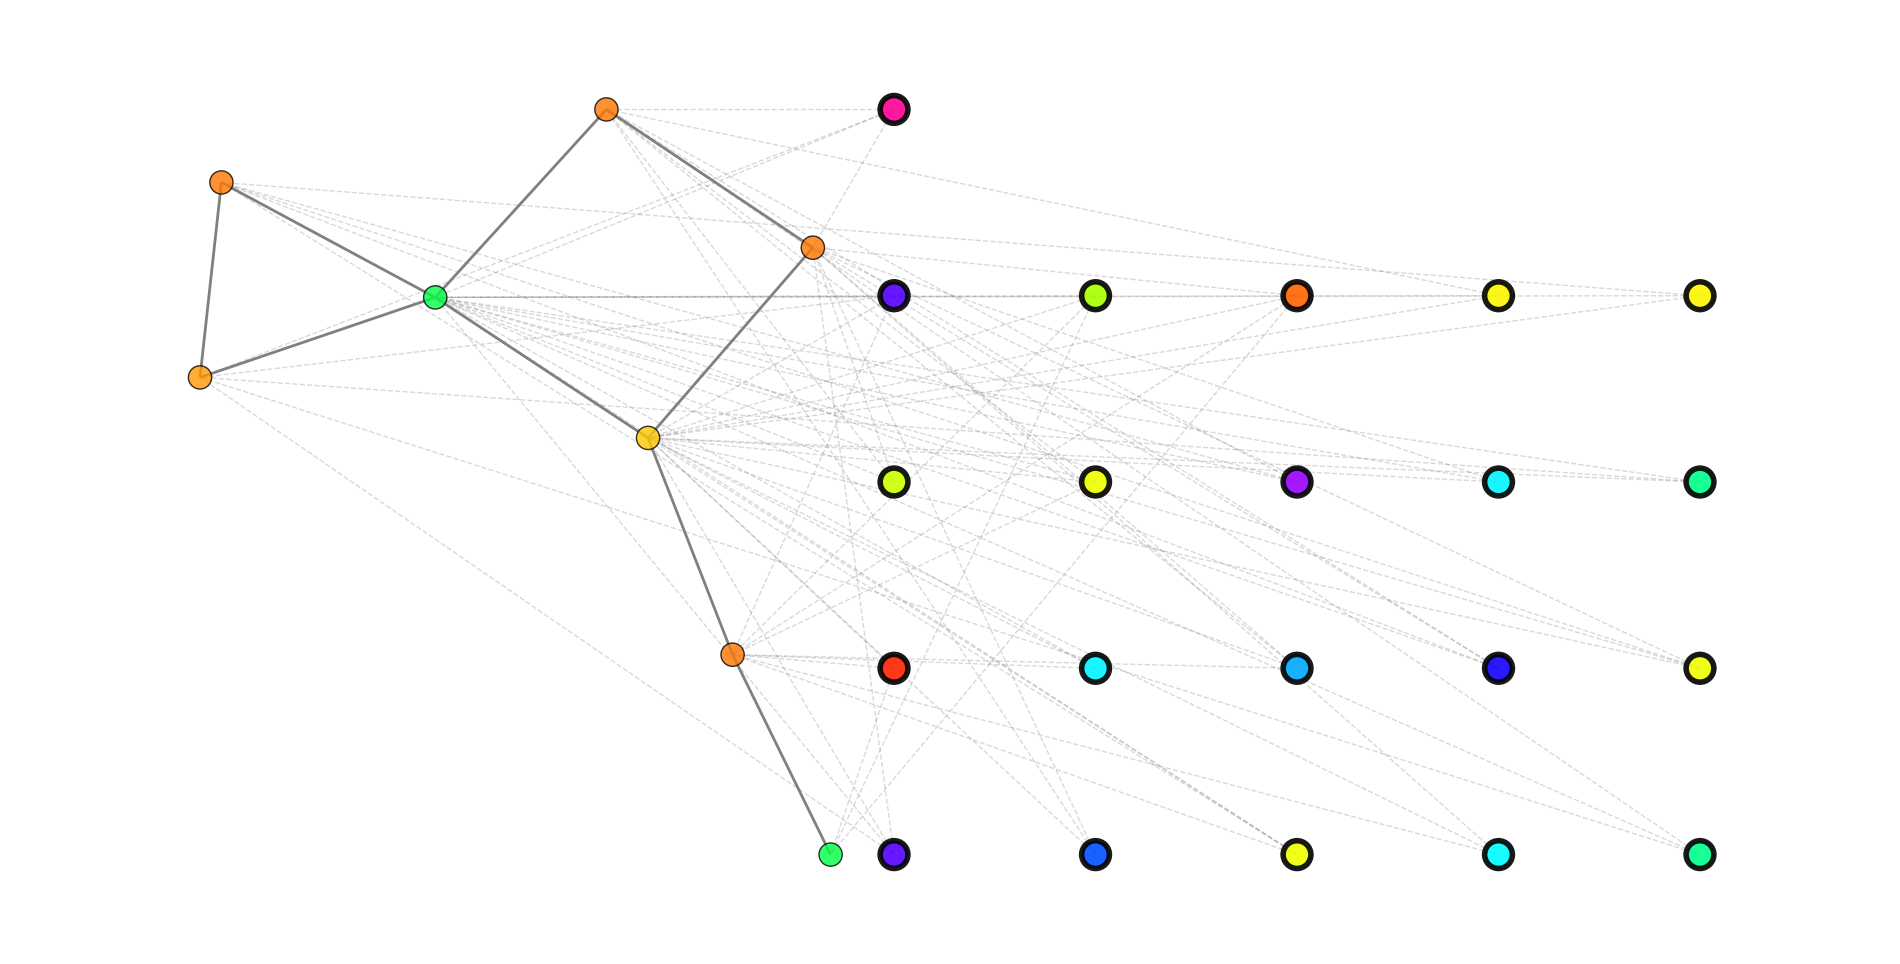

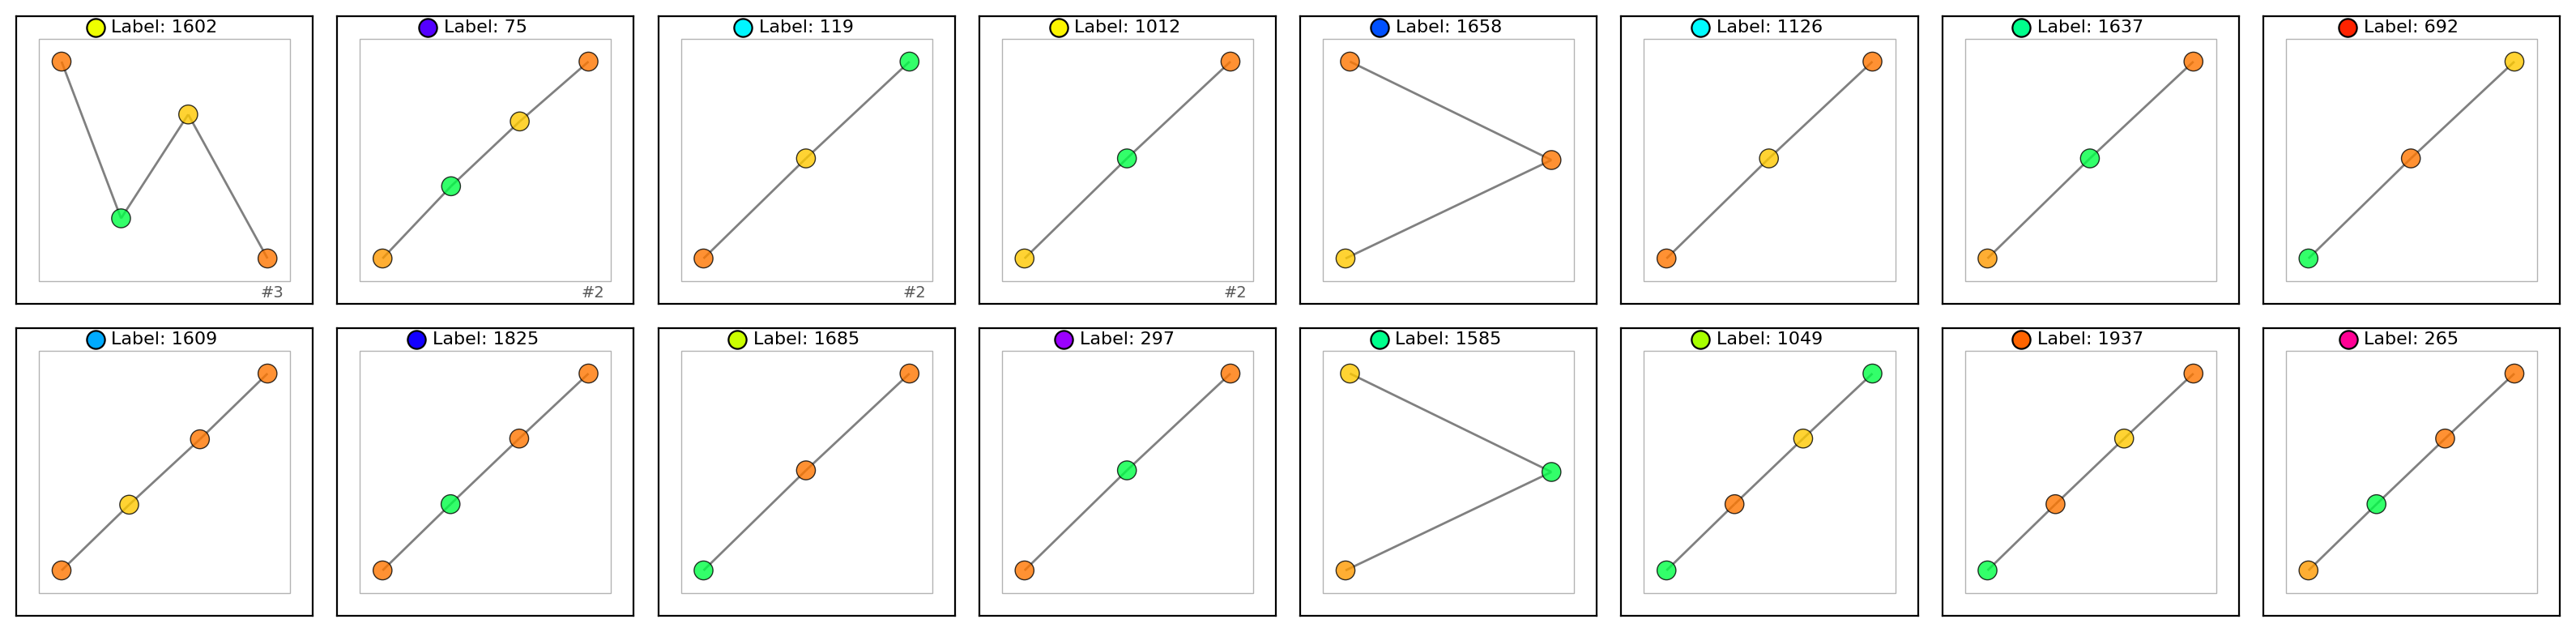

In [11]:
df = path(number_of_edges=(2, 3))
path_ag = draw(graph, df)


## `spine(radius=1)`

`spine` selects one random longest path in the mapped subgraph and then thickens it by including nodes within the requested hop radius around that path.

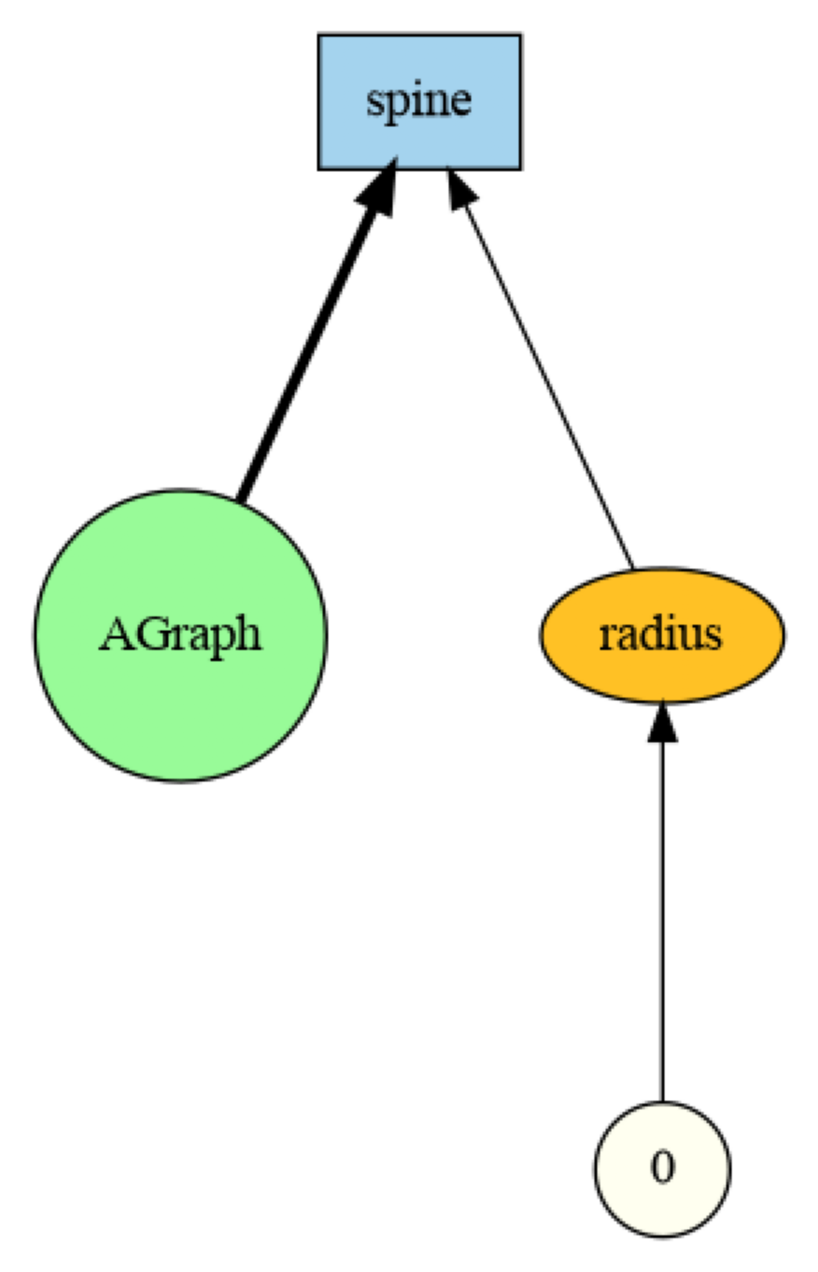

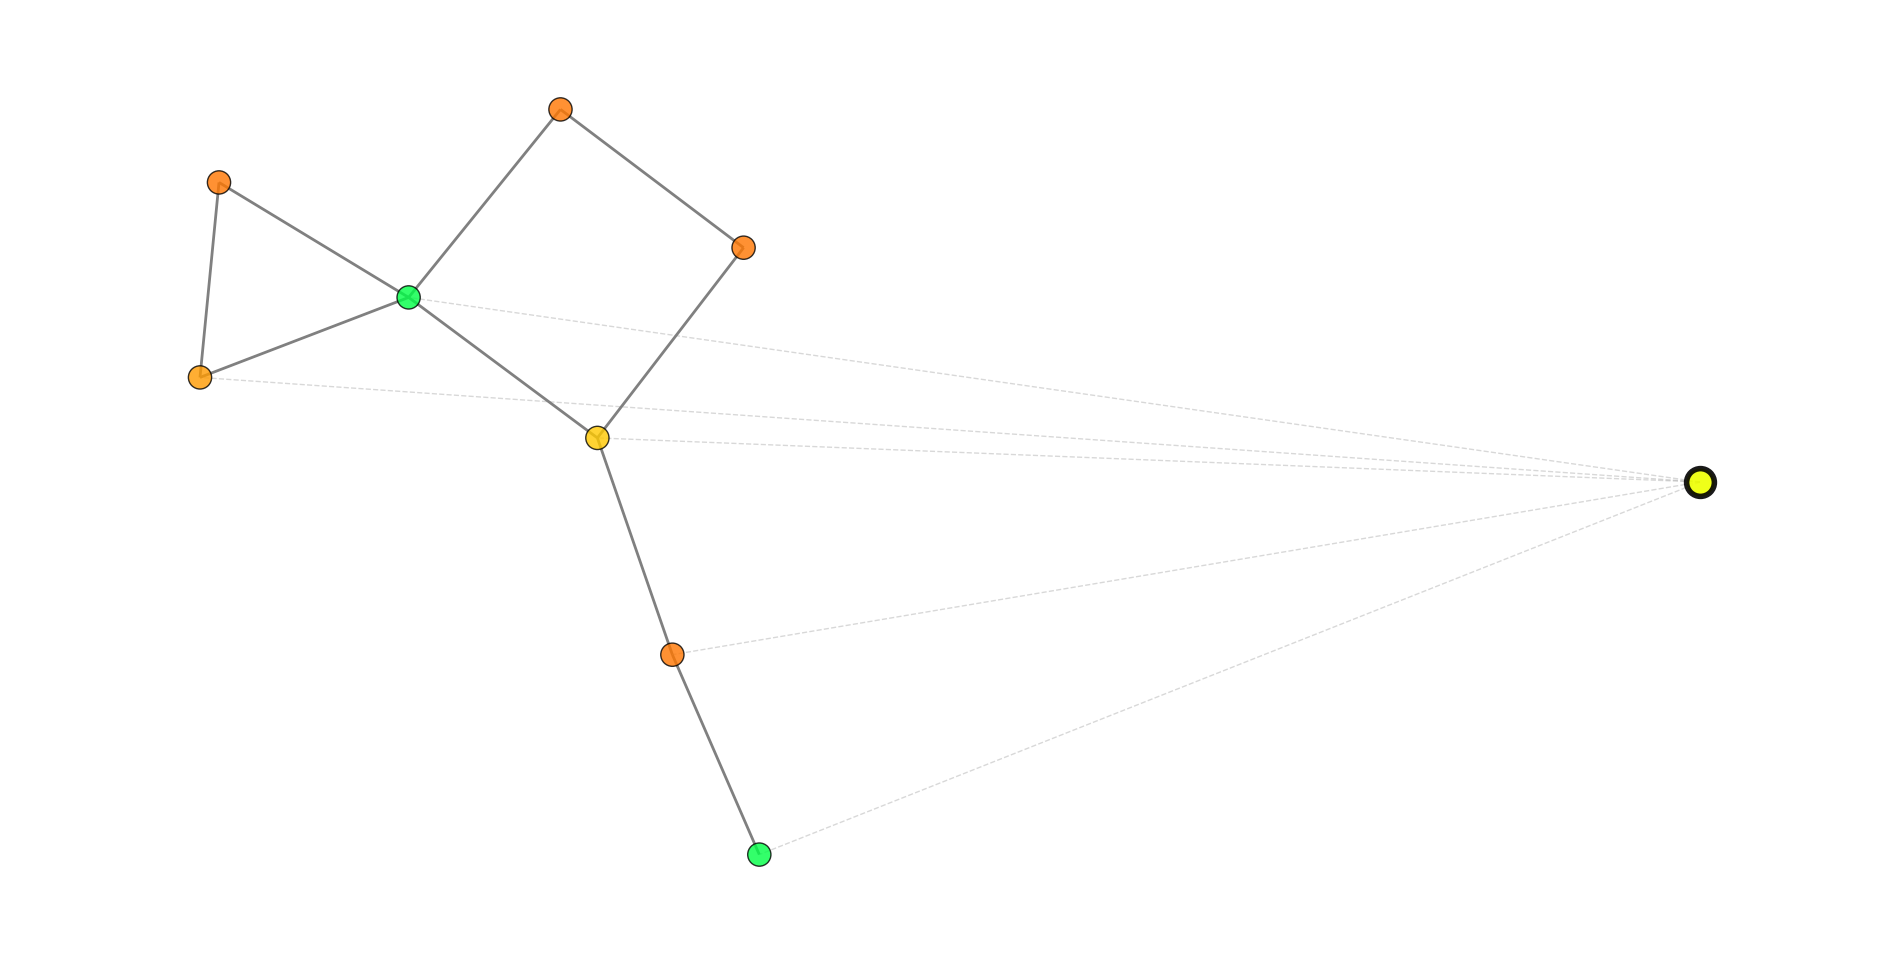

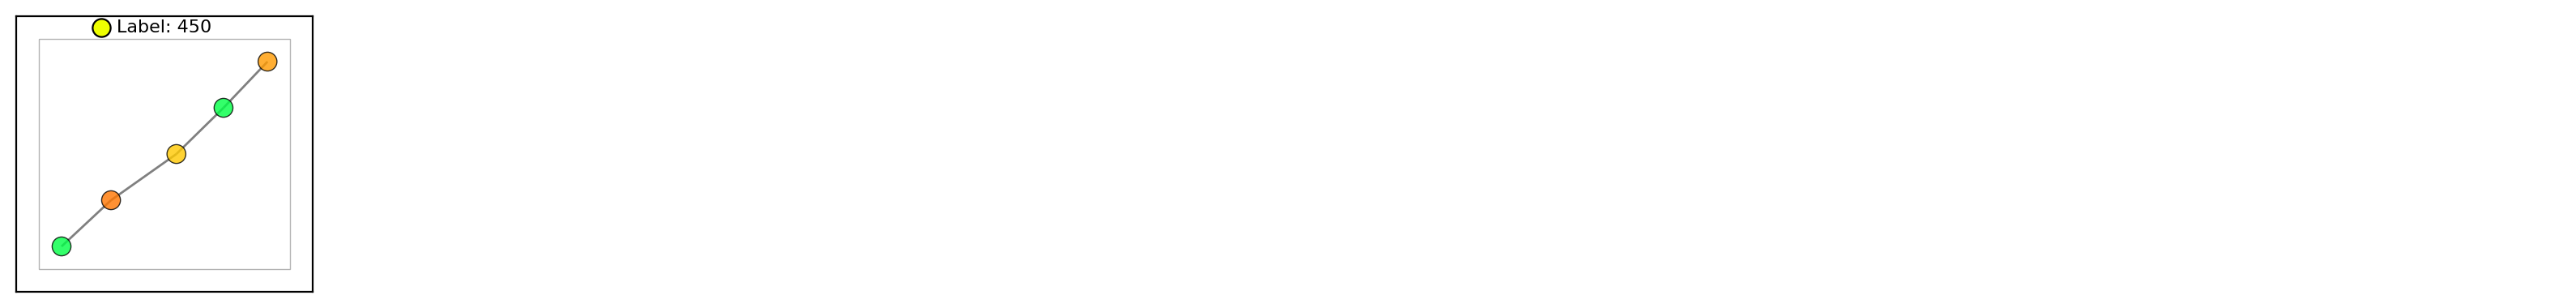

In [12]:
df = spine(radius=0)
spine_ag = draw(graph, df)

## `graphlet(radius=1, number_of_nodes=(3, 4))`

Graphlets are small local induced subgraphs. They are often useful as a bridge between local neighborhoods and motif-style features.


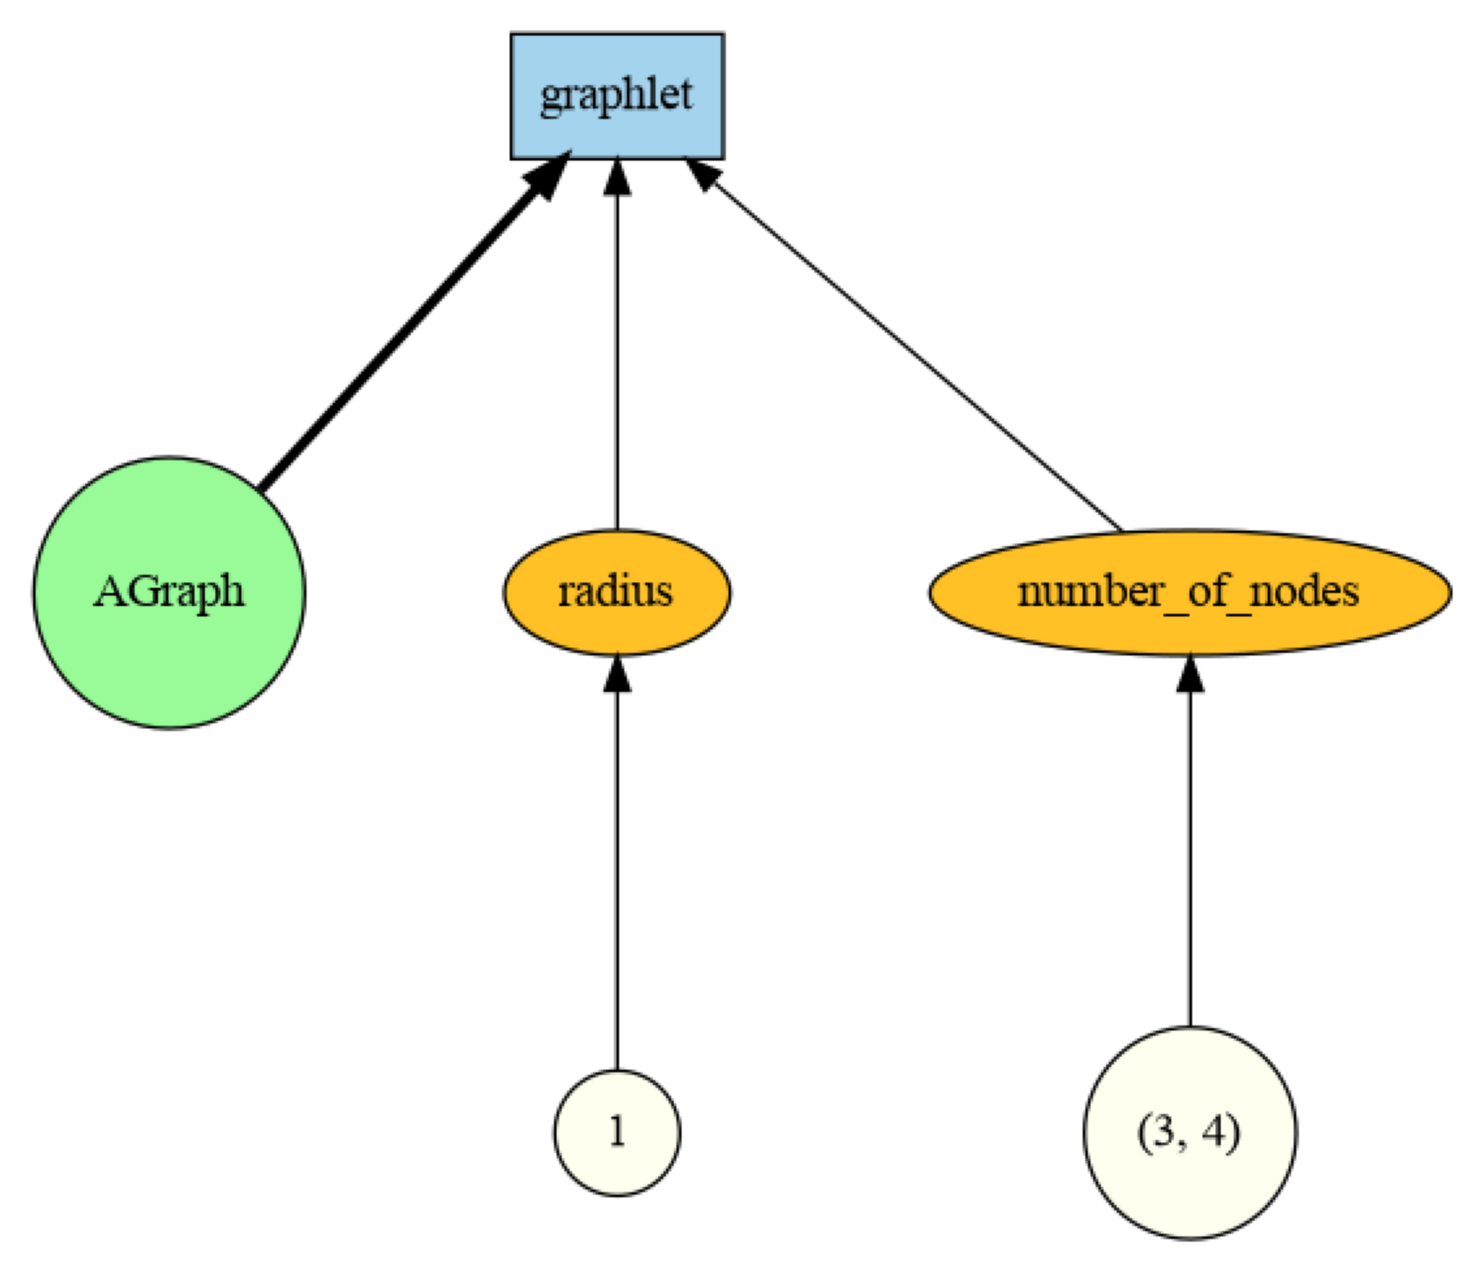

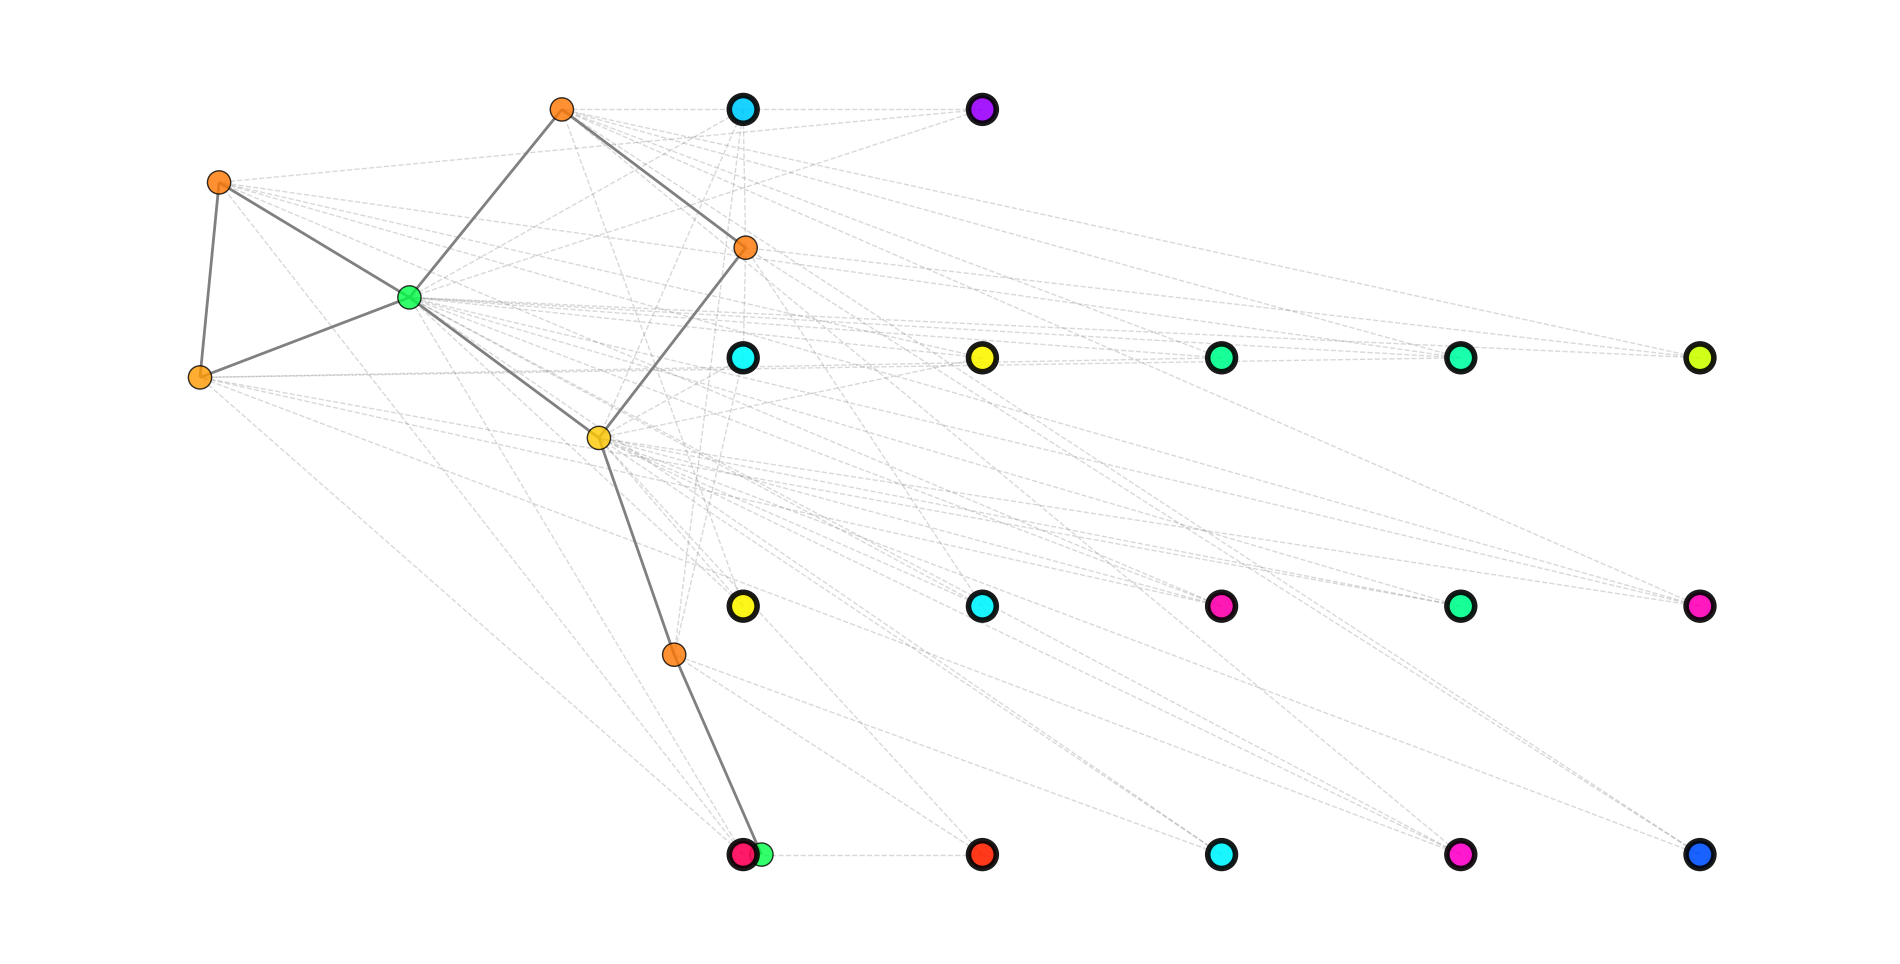

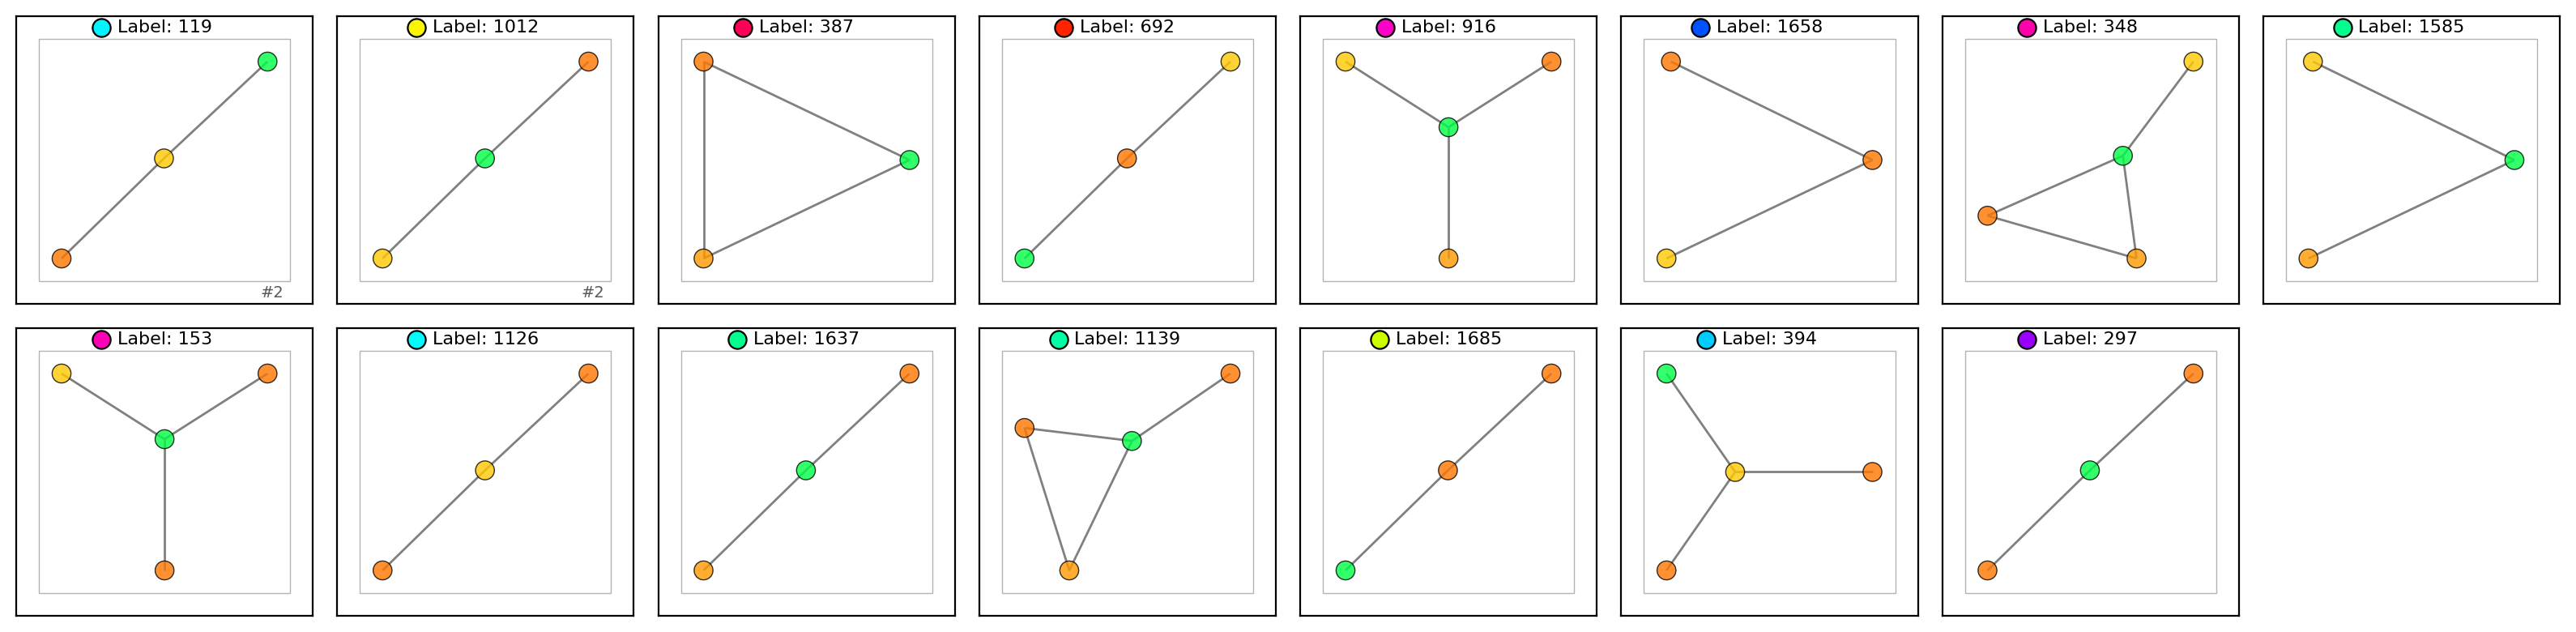

In [13]:
df = graphlet(radius=1, number_of_nodes=(3, 4))
graphlet_ag = draw(graph, df)


## `clique(number_of_nodes=(3, 4))`

Clique decomposition pulls out complete subgraphs. In this toy graph, the triangle should be the main hit.


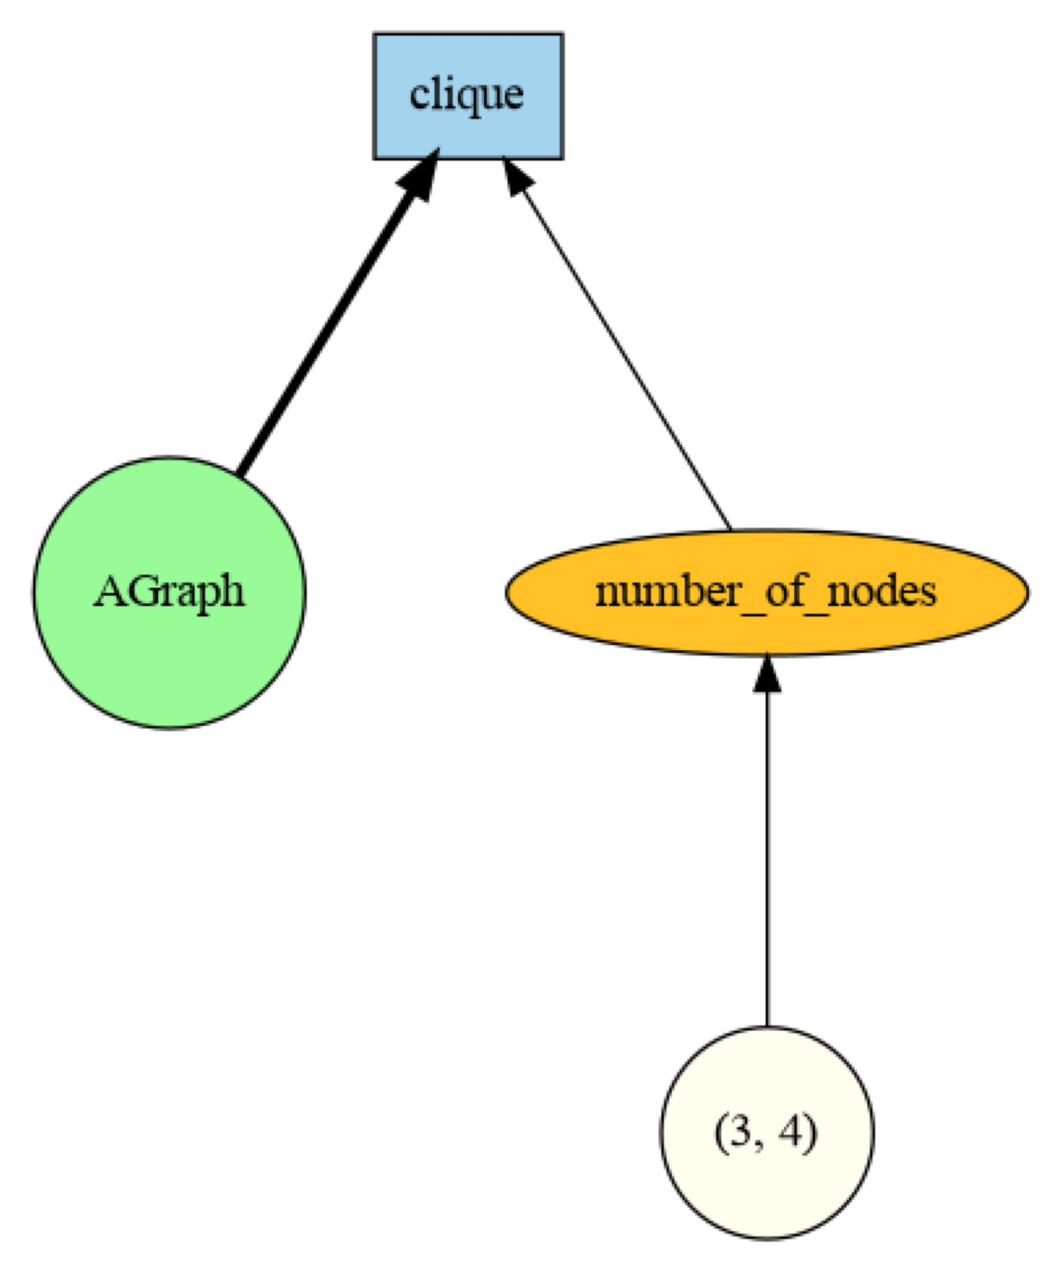

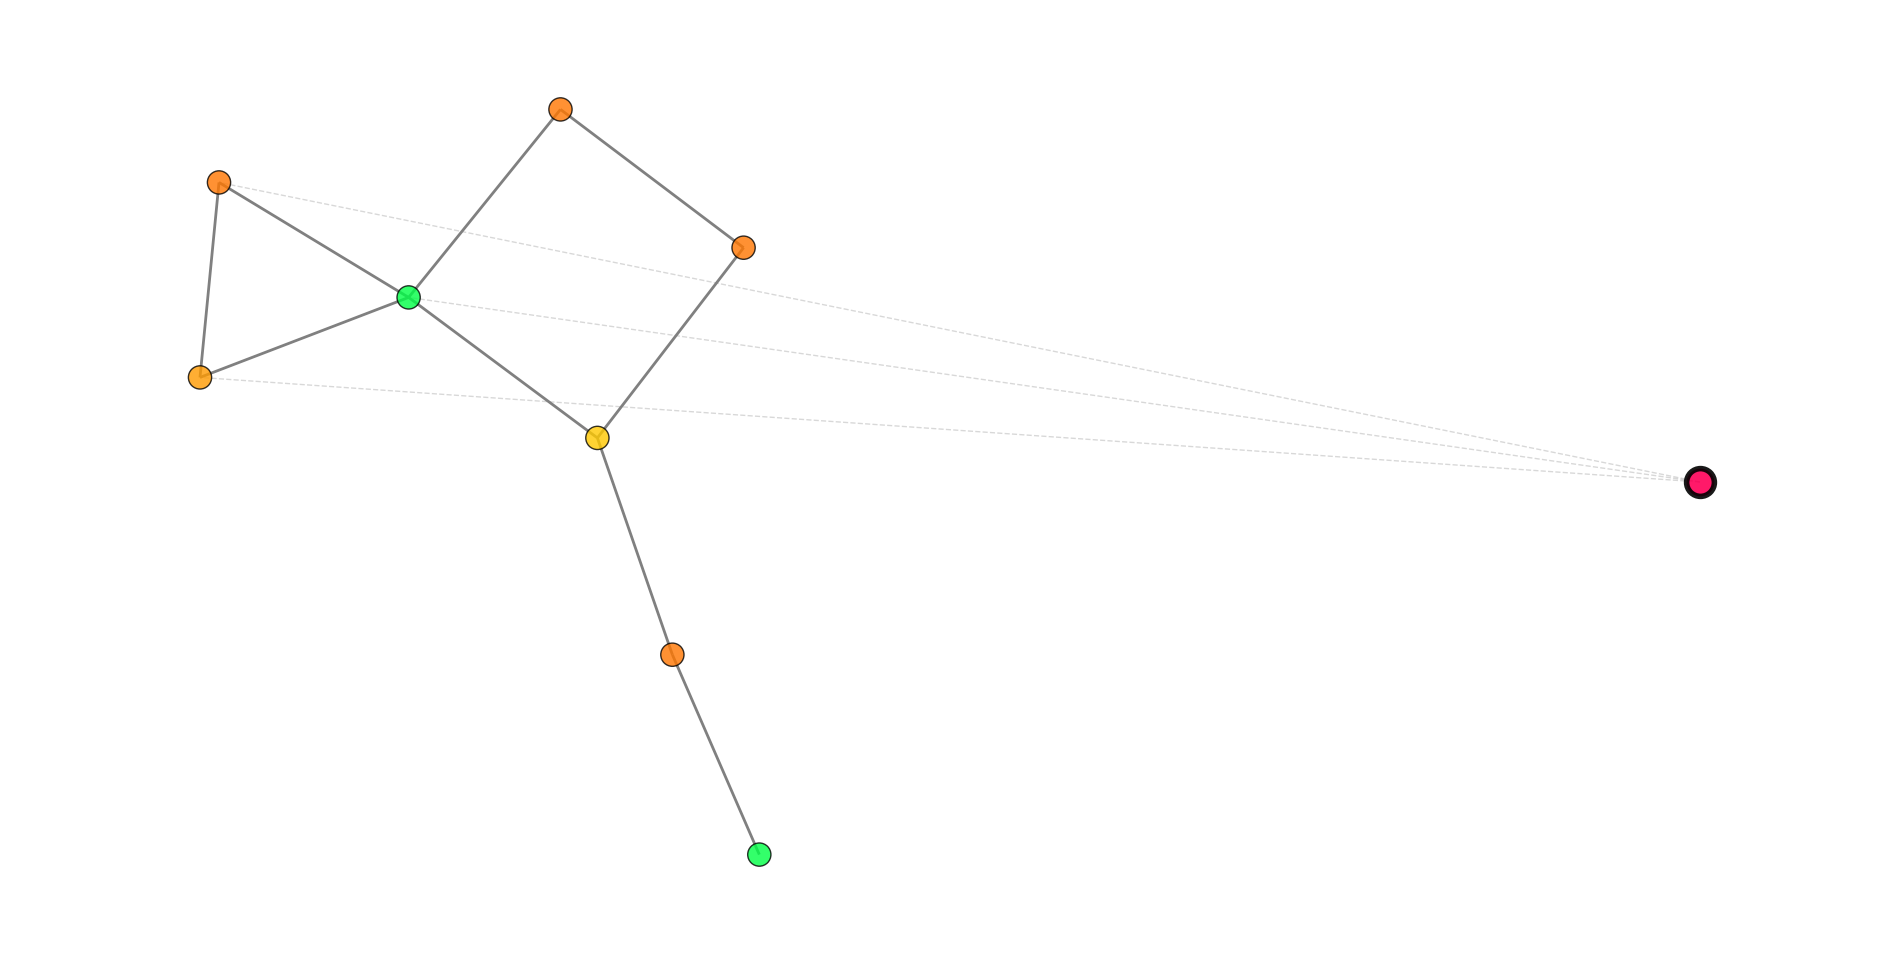

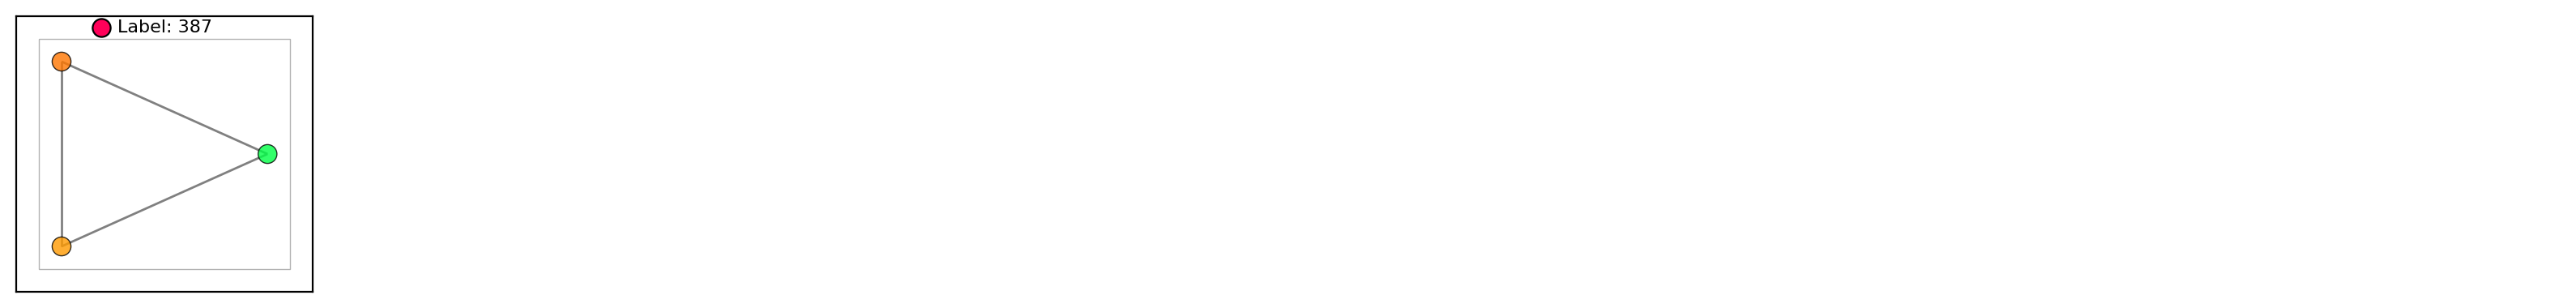

In [14]:
df = clique(number_of_nodes=(3, 4))
clique_ag = draw(graph, df)


## `degree(value=(2, 3))`

`degree` is still unary, but it behaves more like a structural selector: it keeps subgraphs induced by nodes matching a degree range.


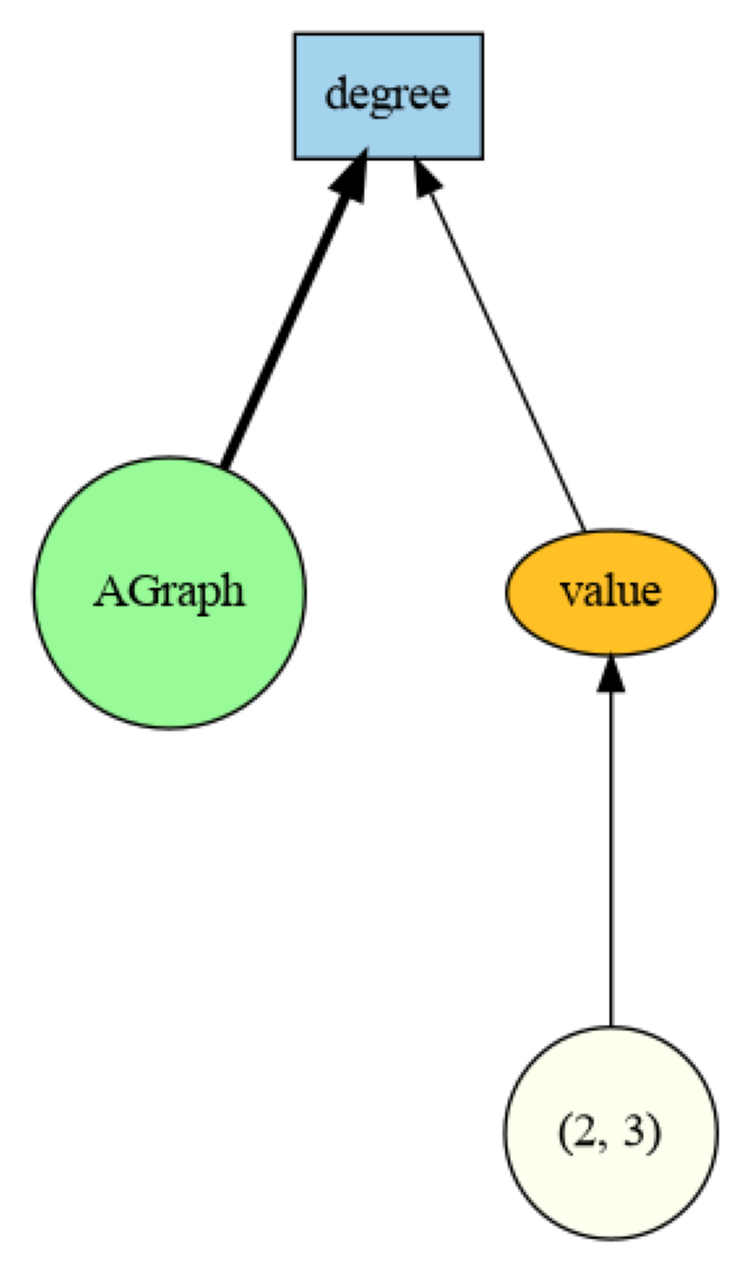

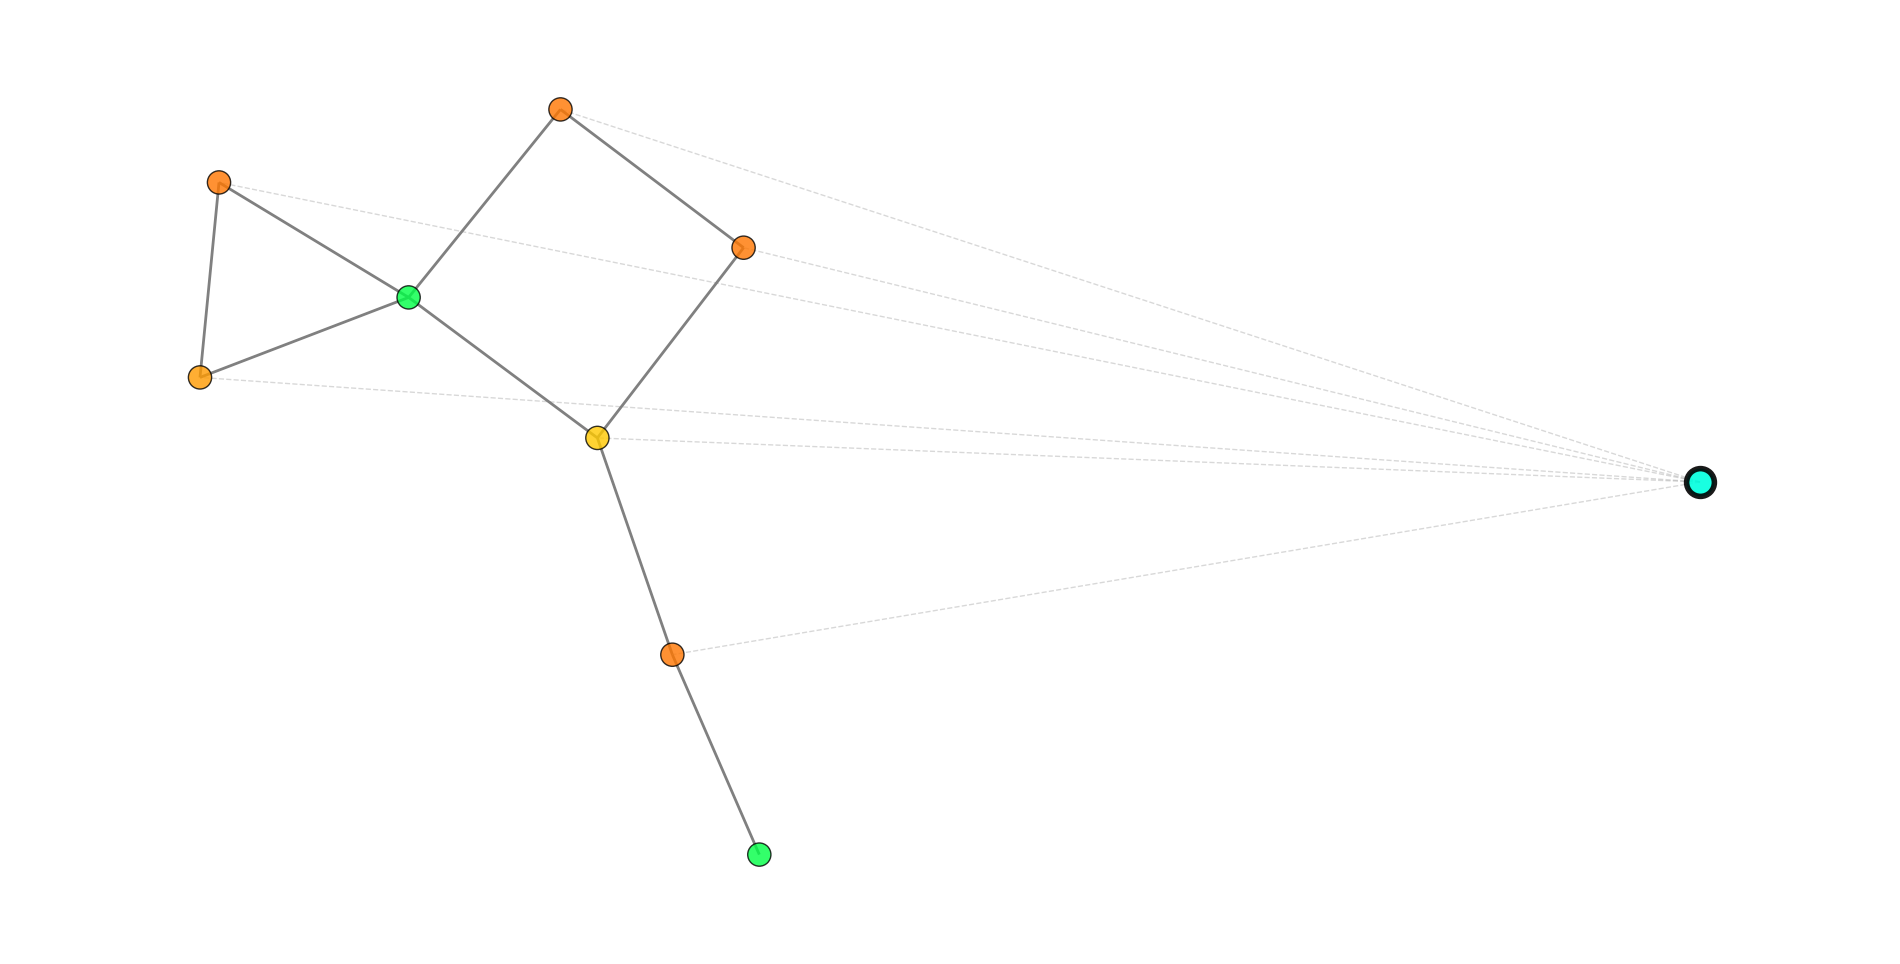

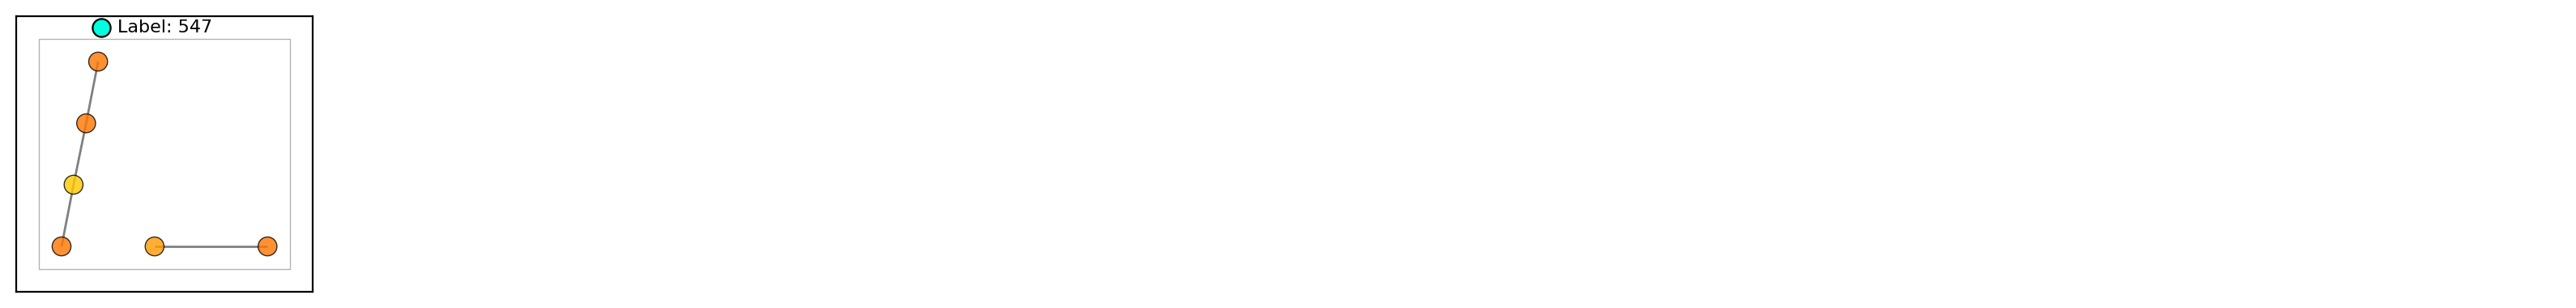

In [15]:
df = degree(value=(2, 3))
degree_ag = draw(graph, df)


## `betweenness_centrality(number_of_nodes=3)`

This operator selects structurally central nodes before lifting them into mapped subgraphs.


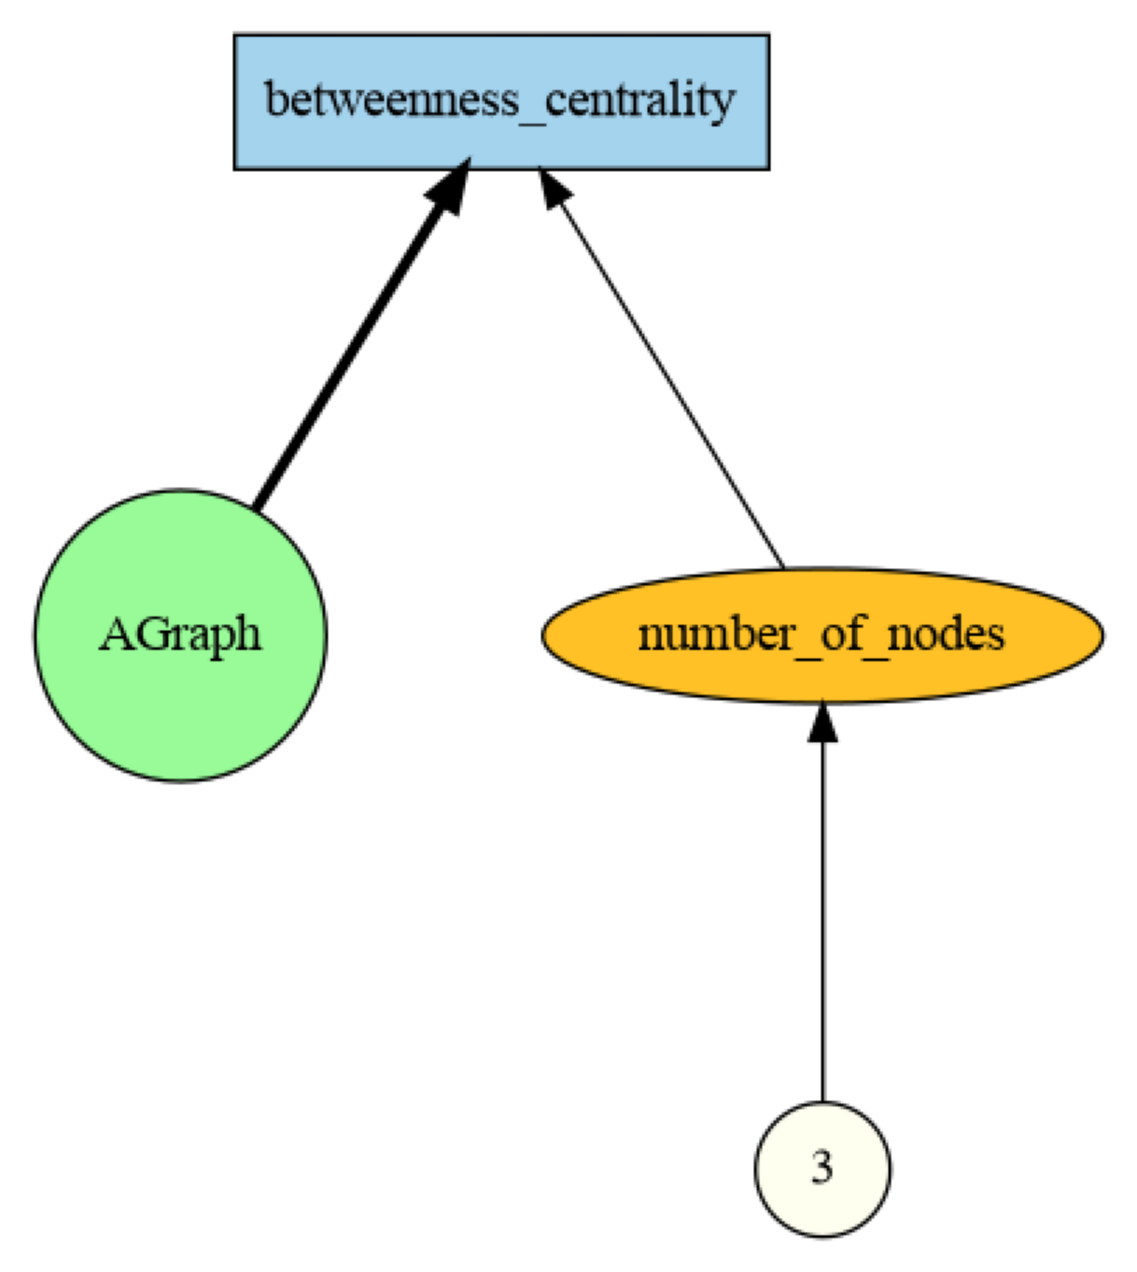

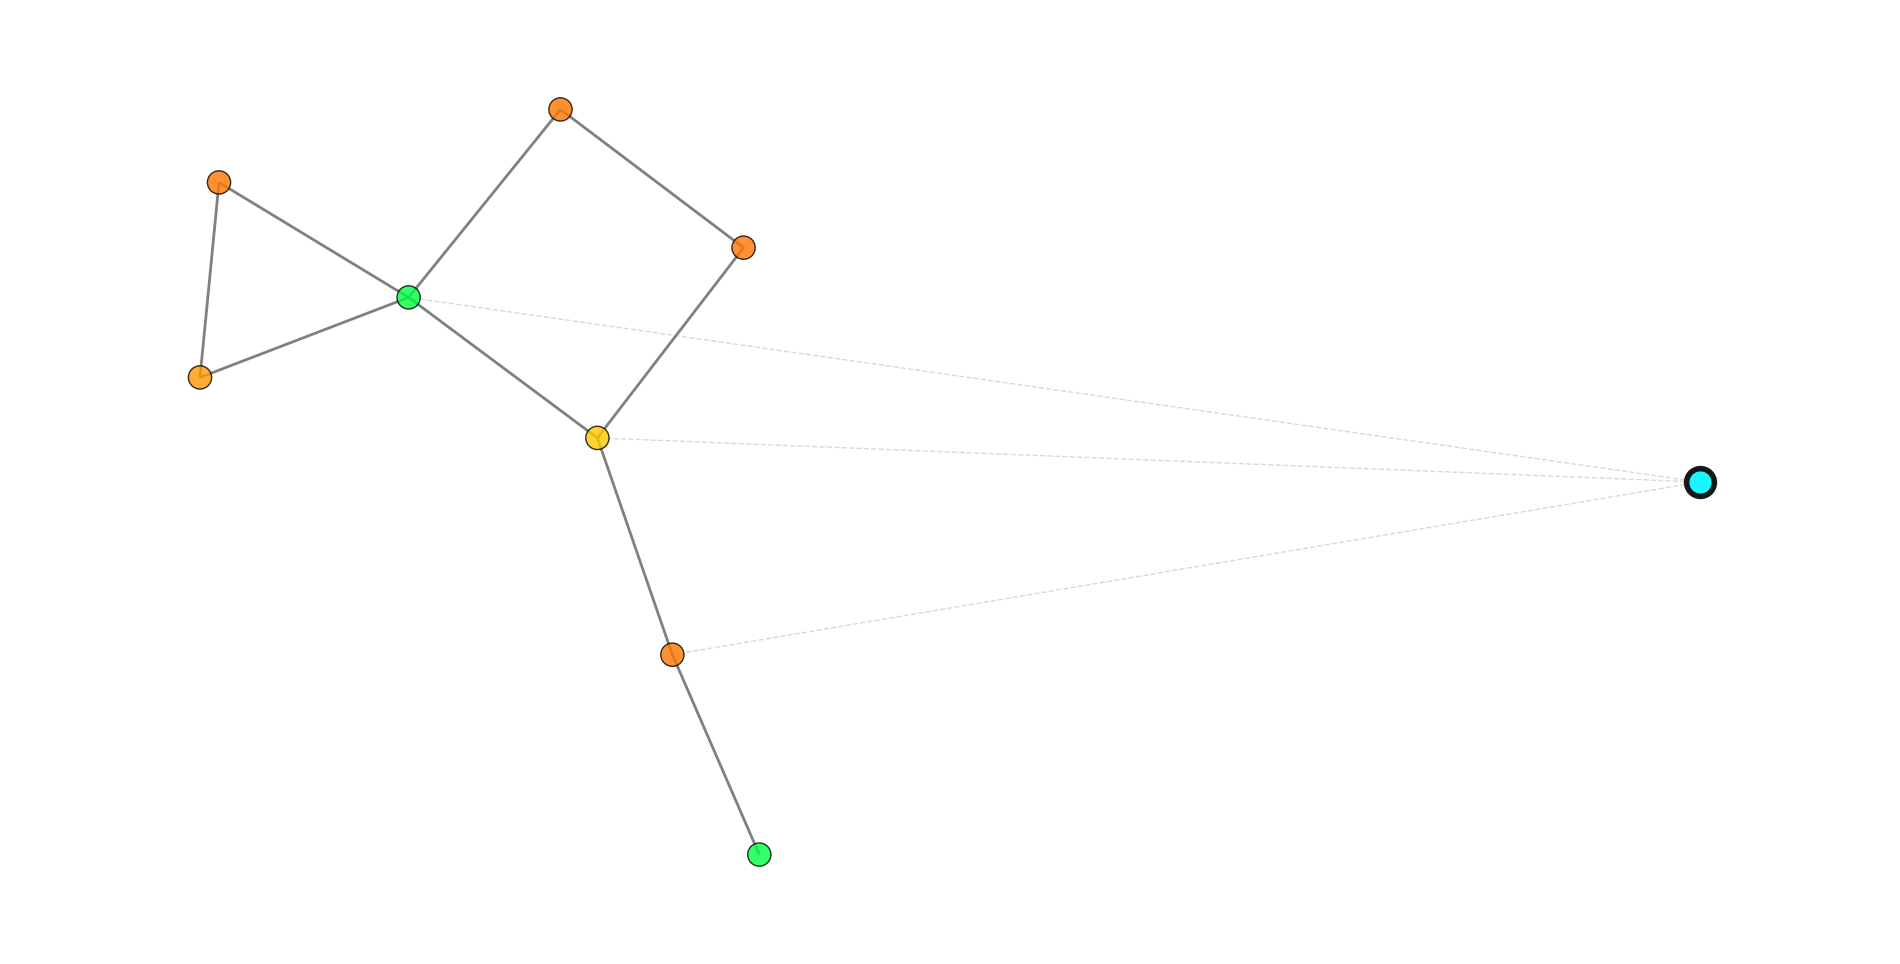

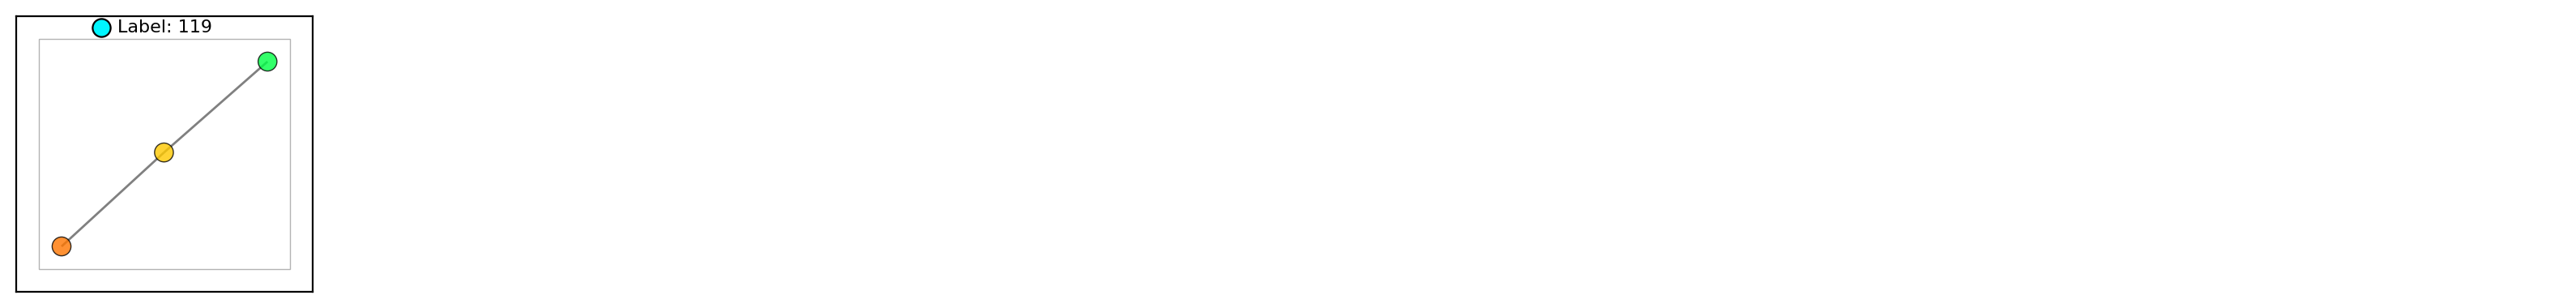

In [16]:
df = betweenness_centrality(number_of_nodes=3)
betweenness_ag = draw(graph, df)


## Summary

Unary decompositions give you the first layer of vocabulary for an `AbstractGraph`: nodes, edges, local neighborhoods, motifs, paths, cliques, and centrality-driven selections. The next notebook in the sequence should build on this by showing how these unary pieces are combined, filtered, and composed into richer operator pipelines.

Next: [02 Composition And Add](./example_abstract_graph_operators_02_composition_and_add.ipynb)
